## Proyecto final análisis violencia de genero

In [1]:
# Cargue de librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import EllipticEnvelope
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configurar pandas para mostrar más columnas
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

print('Librerias cargadas de manera exitosa')

Librerias cargadas de manera exitosa


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# cargue del dataset

# Cargar dataset
df = pd.read_csv("/content/drive/MyDrive/forte/proyecto final/sivigila_violencia.csv")

# Mostrar información básica
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas")

print(f"\nPrimeras filas del dataset:")
df.head(5)


El dataset tiene 82023 filas y 118 columnas

Primeras filas del dataset:


,cod_eve,fec_not,semana,año,cod_pre,cod_sub,edad_,uni_med_,nacionali_,nombre_nacionalidad,sexo_,cod_pais_o,cod_dpto_o,cod_mun_o,area_,localidad_,cen_pobla_,vereda_,bar_ver_,ocupacion_,tip_ss_,cod_ase_,per_etn_,nom_grupo_,estrato_,...,inf_aut,evi_mlegal,estadotran,edad_agre,hora_hecho,nom_eve,nom_upgd,npais_proce,ndep_proce,nmun_proce,npais_resi,ndep_resi,nmun_resi,ndep_notif,nmun_notif,nreg,clasificación_final,codigo_barrio,codigo_comuna,nombre_barrio,nombre_comuna,grupo_edad_quinque,grupo_edad_ciclo,periodo_epid,mes_caso
0,875,26/09/2018,38,2018,500102178,54,5,1,NaN,NaN,F,170,5,1,1.0,MEDELLIN,NaN,NaN,POPULAR,9997.0,S,ESS024,6.0,NaN,1.0,...,1.0,2.0,1.0,0.0,NaN,VIGILANCIA EN SALUD PÚBLICA DE LA VIOLENCIA DE...,ESE METROSALUD CS SANTO DOMINGO SAVIO,COLOMBIA,ANTIOQUIA,MEDELLIN,COLOMBIA,ANTIOQUIA,MEDELLIN,ANTIOQUIA,MEDELLIN,10468,1,103,1,Popular,01 Popular,5-9,0-5,10,9
1,875,26/09/2018,39,2018,500102178,8,15,1,NaN,NaN,F,170,5,1,1.0,SD,NaN,NaN,LOPEZ DE MESA,9997.0,S,EPSS40,6.0,NaN,1.0,...,2.0,NaN,1.0,0.0,NaN,VIGILANCIA EN SALUD PÚBLICA DE LA VIOLENCIA DE...,ESE METROSALUD UNIDAD HOSPITALARIA CASTILLA,COLOMBIA,ANTIOQUIA,MEDELLIN,COLOMBIA,ANTIOQUIA,MEDELLIN,ANTIOQUIA,MEDELLIN,10374,1,710,7,López de Mesa,07 Robledo,15-19,12-17,10,9
2,875,26/09/2018,39,2018,500180000,1,61,1,NaN,NaN,F,170,5,1,1.0,NaN,NaN,NaN,CARPINELO,9996.0,S,EPSS40,6.0,NaN,NaN,...,2.0,NaN,1.0,2.0,NaN,VIGILANCIA EN SALUD PÚBLICA DE LA VIOLENCIA DE...,COMISARIA DE FAMILIA COMANA 1 SANTO DOMINGO,COLOMBIA,ANTIOQUIA,MEDELLIN,COLOMBIA,ANTIOQUIA,MEDELLIN,ANTIOQUIA,MEDELLIN,19935,1,112,1,Carpinelo,01 Popular,60-64,60 y más,10,9
3,875,26/09/2018,39,2018,500180000,8,35,1,NaN,NaN,F,170,5,1,1.0,NaN,NaN,NaN,LLANADITAS,9999.0,C,EPS010,6.0,NaN,NaN,...,2.0,NaN,1.0,2.0,NaN,VIGILANCIA EN SALUD PÚBLICA DE LA VIOLENCIA DE...,COMISARIA DE FAMILIA COMUNA 8 VILLA HERMOSA,COLOMBIA,ANTIOQUIA,MEDELLIN,COLOMBIA,ANTIOQUIA,MEDELLIN,ANTIOQUIA,MEDELLIN,19894,1,9003,90,Llanaditas,90 Corregimiento de Santa Elena,35-39,29-59,10,9
4,875,26/09/2018,39,2018,500180000,15,6,1,NaN,NaN,F,170,5,1,1.0,NaN,NaN,NaN,LA COLINA,9999.0,I,NaN,6.0,NaN,NaN,...,2.0,NaN,1.0,2.0,NaN,VIGILANCIA EN SALUD PÚBLICA DE LA VIOLENCIA DE...,COMISARIA DE FAMILIA COMUNA 15 GUAYABAL,COLOMBIA,ANTIOQUIA,MEDELLIN,COLOMBIA,ANTIOQUIA,MEDELLIN,ANTIOQUIA,MEDELLIN,12606,1,1511,15,La Colina,15 Guayabal,5-9,6-11,10,9


In [4]:

 # Inspeccionar columnas relevantes
columnas_relevantes = [
    "fec_hecho",        # Fecha del hecho
    "sexo_",            # Sexo de la víctima
    "edad_",            # Edad de la víctima
    "estrato_",         # estrato social
    "grupo_edad_ciclo", # Grupo etario
    "nombre_comuna",    # Comuna
    "codigo_comuna",     # Codigo de comuna
    "nombre_barrio",    # Barrio
    "sexo_agre",        # Sexo del agresor
    "orient_sex",       # Orientación sexual
    "ident_gene",       # Identidad de género
    "nom_eve",           # Tipo de evento
    "nom_upgd",          # atencion medica
    "naturaleza",        # fisica, sexual
    "r_fam_vic",        # quien fue el agresor
    "fec_not",          # fecha de notificacion
]

df_relevante = df[columnas_relevantes]

print("--- Resumen de Tipos de Datos e Información ---")

df_relevante.info()




--- Resumen de Tipos de Datos e Información ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82023 entries, 0 to 82022
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fec_hecho         82022 non-null  object 
 1   sexo_             82023 non-null  object 
 2   edad_             82023 non-null  int64  
 3   estrato_          27099 non-null  float64
 4   grupo_edad_ciclo  82023 non-null  object 
 5   nombre_comuna     82023 non-null  object 
 6   codigo_comuna     82023 non-null  int64  
 7   nombre_barrio     82021 non-null  object 
 8   sexo_agre         75872 non-null  object 
 9   orient_sex        68742 non-null  float64
 10  ident_gene        68742 non-null  float64
 11  nom_eve           82023 non-null  object 
 12  nom_upgd          80376 non-null  object 
 13  naturaleza        56561 non-null  float64
 14  r_fam_vic         81709 non-null  float64
 15  fec_not           82023 non-null  objec

La columna "fec_hecho", "fec_not" no tiene el formato de fecha

In [5]:
# Verificar valores faltantes en áreas principales
# 1. Ver cantidad absoluta de faltantes
print("=== Cantidad de valores faltantes ===")
print(df[columnas_relevantes].isna().sum())

print("\n=== Porcentaje de valores faltantes ===")
# 2. Cálculo correcto: (suma / total) * 100 y luego redondear
porcentaje_nulos = (df[columnas_relevantes].isna().sum() / len(df)) * 100
print(porcentaje_nulos.round(2))

=== Cantidad de valores faltantes ===
fec_hecho               1
sexo_                   0
edad_                   0
estrato_            54924
grupo_edad_ciclo        0
nombre_comuna           0
codigo_comuna           0
nombre_barrio           2
sexo_agre            6151
orient_sex          13281
ident_gene          13281
nom_eve                 0
nom_upgd             1647
naturaleza          25462
r_fam_vic             314
fec_not                 0
dtype: int64

=== Porcentaje de valores faltantes ===
fec_hecho            0.00
sexo_                0.00
edad_                0.00
estrato_            66.96
grupo_edad_ciclo     0.00
nombre_comuna        0.00
codigo_comuna        0.00
nombre_barrio        0.00
sexo_agre            7.50
orient_sex          16.19
ident_gene          16.19
nom_eve              0.00
nom_upgd             2.01
naturaleza          31.04
r_fam_vic            0.38
fec_not              0.00
dtype: float64


# Limpieza y transformación de datos

In [6]:
# copia del dataframe

df_limpio = df[columnas_relevantes].copy()

In [7]:
# Eliminar posibles espacios en blanco residuales en todas las columnas tipo object
df_limpio = df_limpio.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [8]:

# Inspeccionar duplicados


# Calcular el número de duplicados

num_duplicados = df.duplicated().sum()

print(f"Duplicados encontrados: {num_duplicados:,}")

# 2. porcentaje
porcentaje_duplicados = (num_duplicados / len(df)) * 100

# 3. Eliminar duplicados

df_clear = df.drop_duplicates()

print(f"Porcentaje de duplicados: {porcentaje_duplicados:.2f}%")
print(f"{num_duplicados:,} duplicados eliminados")
print(f"Registros después de eliminar duplicados: {len(df_clear):,}")


print(f"Duplicados eliminados: {num_duplicados} ({porcentaje_duplicados:.2f}%)")


Duplicados encontrados: 2
Porcentaje de duplicados: 0.00%
2 duplicados eliminados
Registros después de eliminar duplicados: 82,021
Duplicados eliminados: 2 (0.00%)


In [9]:
# conversión variable a texto
df_limpio['nombre_comuna'] = df_limpio['nombre_comuna'].astype(str)

# Esto verifica si hay algo raro y lo limpia
df_limpio['nombre_comuna'] = df_limpio['nombre_comuna'].str.upper().str.strip()

In [10]:
# Corregir variaciones comunes en 'sexo' si existen
df_limpio['sexo_'] = df_limpio['sexo_'].replace({'MASCULINO': 'M', 'FEMENINO': 'F'})
df_limpio['sexo_agre'] = df_limpio['sexo_agre'].replace({'MASCULINO': 'M', 'FEMENINO': 'F'})

In [11]:
# ==========================================================
# CONSISTENCIA Y CALIDAD TEMPORAL (CON IMPUTACIÓN)
# ==========================================================

# 1. Conversión a formato fecha
df_limpio["fec_hecho"] = pd.to_datetime(df_limpio["fec_hecho"], errors="coerce")
df_limpio["fec_not"] = pd.to_datetime(df_limpio["fec_not"], errors="coerce")

# 2. Extraer años iniciales para diagnóstico
df_limpio['anio_hecho_orig'] = df_limpio['fec_hecho'].dt.year

# 3. Identificar registros con fechas inválidas (antes de 2017 o nulas)
# Creamos una máscara booleana
mask_invalida = (df_limpio['anio_hecho_orig'] < 2017) | (df_limpio['fec_hecho'].isna())

# 4. IMPUTACIÓN: Si el hecho es inválido, usamos la notificación
# Creamos una columna para saber qué datos fueron "ajustados"
df_limpio['fecha_imputada'] = False
df_limpio.loc[mask_invalida, 'fecha_imputada'] = True

# Realizamos el reemplazo
df_limpio.loc[mask_invalida, 'fec_hecho'] = df_limpio.loc[mask_invalida, 'fec_not']

# 5. Recalcular años y estado final
df_limpio['anio_hecho'] = df_limpio['fec_hecho'].dt.year
df_limpio['anio_not'] = df_limpio['fec_not'].dt.year

def estado_fecha(anio, inicio=2017, fin=2023):
    if pd.isna(anio): return "Fecha nula"
    elif anio < inicio: return "Fuera de rango inferior"
    elif anio > fin: return "Fuera de rango superior"
    else: return "Fecha válida"

df_limpio['estado_hecho_final'] = df_limpio['anio_hecho'].apply(estado_fecha)

# 6. Diferencia en días (ahora será 0 para los imputados)
df_limpio['dias_diferencia'] = (df_limpio['fec_not'] - df_limpio['fec_hecho']).dt.days

# 7. Limpieza de inconsistencias críticas restantes
# (Por ejemplo, si después de la corrección la notificación sigue siendo ANTERIOR al hecho)
df_limpio = df_limpio[df_limpio['dias_diferencia'] >= 0].copy()

# ==========================================================
# REPORTES DE CALIDAD
# ==========================================================
print(f"Registros totales recuperados mediante imputación: {df_limpio['fecha_imputada'].sum()}")
print("\nResumen calidad fecha del hecho FINAL:")
print(df_limpio['estado_hecho_final'].value_counts())

print("\nRegistros finales para el análisis:", len(df_limpio))

Registros totales recuperados mediante imputación: 14079

Resumen calidad fecha del hecho FINAL:
estado_hecho_final
Fecha válida               69407
Fuera de rango inferior    12413
Name: count, dtype: int64

Registros finales para el análisis: 81820


In [12]:
# Filtrar solo los registros que están dentro del periodo de interés (2017-2023)
df_analisis = df_limpio[df_limpio['estado_hecho_final'] == "Fecha válida"].copy()

# columna de Mes-Año para agrupar
df_analisis['mes_hecho'] = df_analisis['fec_hecho'].dt.to_period('M')

# Contar casos por mes
serie_tiempo = df_analisis.groupby('mes_hecho').size()

print(f"Registros listos para la serie de tiempo: {len(df_analisis)}")

Registros listos para la serie de tiempo: 69407


Para garantizar la integridad del análisis de series temporales, se realizó un proceso de auditoría sobre las variables cronológicas. Se detectó que un 15% de los registros presentaban inconsistencias críticas (valores atípicos fuera del rango biológico y administrativo, como años 1900 o anteriores a 2017).

Siguiendo protocolos de limpieza de datos epidemiológicos, se aplicó una imputación lógica utilizando la fecha de notificación como proximidad para rescatar el volumen total de casos. No obstante, aquellos registros que, incluso tras la imputación, persistieron fuera del horizonte de estudio (2017-2023), fueron excluidos del análisis de tendencias para evitar sesgos de subregistro histórico y distorsiones en la media de incidencia mensual

In [13]:
# Conversión a entero

# variables
columnas_a_corregir = ["orient_sex", "ident_gene", "naturaleza", "r_fam_vic", "ident_gene"]

for col in columnas_a_corregir:

    temp_series = pd.to_numeric(df_limpio[col], errors='coerce')

    df_limpio[col] = temp_series.round().astype('Int64')

print("Conversión realizada con éxito usando nullable integers (Int64)")

Conversión realizada con éxito usando nullable integers (Int64)


In [14]:
# Imputación de variables categoricas

df_limpio["nom_upgd"] = df_limpio["nom_upgd"].fillna(df_limpio["nom_upgd"].mode()[0])
df_limpio["sexo_agre"] = df_limpio["sexo_agre"].fillna(df_limpio["sexo_agre"].mode()[0])
print(f"Imputación Exitosa")





Imputación Exitosa


In [15]:
# Imputación variable númerica estrato

df_limpio["estrato_"] = df_limpio["estrato_"].fillna(df_limpio["estrato_"].mode()[0])

# Redondear la media al entero más cercano y convertir a entero
df_limpio["estrato_"] = df_limpio["estrato_"].round().astype(int)

print("✓ Estrato convertido a entero (1-6) tras la imputación")

print(f"Imputación Exitosa")



✓ Estrato convertido a entero (1-6) tras la imputación
Imputación Exitosa


In [16]:
# Lista de variables a convertir y normalizar
columnas_codigos = ["orient_sex", "ident_gene", "naturaleza", "r_fam_vic"]

for col in columnas_codigos:
    # Convertir a numérico, forzar errores a NaN, imputar y convertir a entero
    # Usamos 9 para identidad/orientación, 99 para relación y 5 para naturaleza
    val_imputacion = 99 if col == "r_fam_vic" else (5 if col == "naturaleza" else 9)

    df_limpio[col] = pd.to_numeric(df_limpio[col], errors='coerce').fillna(val_imputacion).astype('int64')

In [17]:
# 4. DICCIONARIOS DE MAPEO (Estándar SIVIGILA)
mapeos = {
    'orient_sex': {1:'heterosexual', 2:'homosexual', 3:'bisexual', 4:'otro', 5:'indeterminado', 9:'sin dato'},
    'naturaleza': {1:'fisica', 2:'psicologica', 3:'sexual', 4:'negligencia/abandono', 5:'no especificado en ficha'},
    'ident_gene': {1:'masculino', 2:'femenino', 3:'transgénero', 4:'otro', 9:'sin dato'},
    'r_fam_vic': {
        1:'pareja', 2:'ex-pareja', 3:'padre/Madre', 4:'hijo/a', 5:'hermano/a',
        6:'otro familiar', 7:'conyuge', 8:'compañero permanente', 10:'tio/a',
        11:'primo/a', 12:'abuelo/a', 13:'sobrino/a', 14:'padrastro', 15:'madrastra',
        16:'hijastro/a', 20:'novio/a', 21:'ex-novio/a', 22:'amigo/a', 23:'vecino/a',
        24:'conocido/a', 25:'desconocido', 30:'patron/jefe', 31:'compañero de trabajo',
        32:'docente', 99:'sin dato'
    }
}

# Aplicar mapeos dinámicamente para crear columnas nominales (_nom)
for col, dicc in mapeos.items():
    # .get() asegura que si aparece un código nuevo, no genere NaN sino 'sin dato'
    df_limpio[f'{col}_nom'] = df_limpio[col].apply(lambda x: dicc.get(x, 'sin dato'))

In [18]:
# Creación de los bins en el dataframe limpio
bins = [0, 12, 18, 28, 59, 110]
labels = ['Infancia', 'Adolescencia', 'Juventud', 'Adultez', 'Persona Mayor']

# Creamos la nueva columna
df_limpio['ciclo_vital'] = pd.cut(df_limpio['edad_'], bins=bins, labels=labels, right=False)


In [19]:
# 5. VARIABLES TEMPORALES Y DERIVADAS
print("\nCreando variables temporales...")
df_limpio["fec_hecho"] = pd.to_datetime(df_limpio["fec_hecho"], errors="coerce")
df_limpio["fec_not"] = pd.to_datetime(df_limpio["fec_not"], errors="coerce")

# Extracción de componentes
df_limpio['Anio'] = df_limpio['fec_hecho'].dt.year
df_limpio['Mes'] = df_limpio['fec_hecho'].dt.month
df_limpio['Trimestre'] = df_limpio['fec_hecho'].dt.quarter
df_limpio['Semestre'] = np.where(df_limpio['Mes'] <= 6, 1, 2)
df_limpio['Mes_nombre'] = df_limpio['fec_hecho'].dt.month_name()
df_limpio['dia_nombre'] = df_limpio['fec_not'].dt.day_name()
df_limpio['es_fin_semana'] = df_limpio['fec_not'].dt.dayofweek >= 5

print("   ✓ Variables temporales creadas: Anio, Mes, Trimestre, Semestre, Mes_nombre")

print("   ✓ Nivel_casos creado (categorización)")

print(f"\nTotal de columnas después de derivadas: {len(df_limpio.columns)}")


Creando variables temporales...
   ✓ Variables temporales creadas: Anio, Mes, Trimestre, Semestre, Mes_nombre
   ✓ Nivel_casos creado (categorización)

Total de columnas después de derivadas: 34


In [20]:
print(f"✓ Proceso finalizado. Columnas totales: {len(df_limpio.columns)}")

✓ Proceso finalizado. Columnas totales: 34


In [21]:
# ==========================================================
# REPORTE FINAL DE AUDITORÍA MEJORADO
# ==========================================================


# Guardamos cuántos registros hay antes de filtrar por fecha
registros_antes_filtrar_fecha = len(df_limpio)

# filtro
df_limpio = df_limpio[df_limpio['dias_diferencia'] >= 0].copy()

# DEFINICION DE LA VARIABLE
eliminados_por_fecha = registros_antes_filtrar_fecha - len(df_limpio)



registros_originales = len(df)
registros_finales = len(df_limpio)

eliminados_duplicados = num_duplicados
eliminados_fecha = eliminados_por_fecha
eliminados_totales = registros_originales - registros_finales

porcentaje_eliminado = (eliminados_totales / registros_originales) * 100

# Nulos originales
nulos_originales = df.isnull().sum().sum()
porcentaje_nulos_original = (nulos_originales / (df.shape[0] * df.shape[1])) * 100

# Verificación de NaN reales en dataset limpio
nulos_finales = df_limpio.isnull().sum().sum()

reporte = pd.DataFrame({
    'Indicador': [
        'Registros originales',
        'Registros finales',
        'Duplicados eliminados',
        'Errores cronológicos eliminados',
        'Total registros eliminados',
        '% registros eliminados',
        'Nulos totales originales',
        '% celdas vacías originales',
        'Nulos técnicos finales (NaN)'
    ],
    'Valor': [
        f"{registros_originales:,}",
        f"{registros_finales:,}",
        f"{eliminados_duplicados:,}",
        f"{eliminados_fecha:,}",
        f"{eliminados_totales:,}",
        f"{porcentaje_eliminado:.3f}%",
        f"{nulos_originales:,}",
        f"{porcentaje_nulos_original:.2f}%",
        f"{nulos_finales:,}"
    ]
})

print("\n" + "="*70)
print("📋 REPORTE DE AUDITORÍA DE CALIDAD DE DATOS")
print("="*70)
display(reporte)
print("="*70)


📋 REPORTE DE AUDITORÍA DE CALIDAD DE DATOS


,Indicador,Valor
0,Registros originales,"82,023"
1,Registros finales,"81,820"
2,Duplicados eliminados,2
3,Errores cronológicos eliminados,0
4,Total registros eliminados,203
5,% registros eliminados,0.247%
6,Nulos totales originales,"2,653,960"
7,% celdas vacías originales,27.42%
8,Nulos técnicos finales (NaN),14


In [22]:
# indicador de densidad informacional por variable crítica

df_limpio[['orient_sex','ident_gene','r_fam_vic']].apply(
    lambda x: (x.isin([9,99])).mean()*100
)

,0
orient_sex,16.231973
ident_gene,16.231973
r_fam_vic,7.159619


El porcentaje % real de “sin dato” por variable. "orient_sex" 16.23%, "ident_gene 16:23% y "r_fam_vic" 7.15%

In [23]:
# Guarda el dataset limpio en un archivo CSV

df_limpio.to_csv('df_limpio.csv', index=False, encoding='utf-8-sig')

print("¡Archivo guardado exitosamente como 'df_limpio.csv'!")

import os
print("Tu archivo se guardó en:")
print(os.getcwd())


¡Archivo guardado exitosamente como 'df_limpio.csv'!
Tu archivo se guardó en:
/content


 * Se realizó la imputación de valores faltantes sobre las variables originales numéricas utilizando la técnica de imputación por categoría constante, asignando los códigos oficiales de 'Sin dato' según el manual de SIVIGILA. Posteriormente, se realizó la expansión del dataset mediante el mapeo de etiquetas semánticas. Debido a un subregistro o valores faltantes del 31.04% en la variable 'naturaleza', se optó por una imputación por categoría constante, clasificando estos registros como 'No especificado'. Esta decisión evita el sesgo de selección y permite visibilizar la brecha en la recolección de información primaria en el sistema de vigilancia.



* Se realizó la expansión del dataset mediante el mapeo de etiquetas semánticas a las variables que contienen codificación, se hizo cambio a categoricas para facilitar el analisis.

* Crearon variables temporales (Anio, Mes, Trimestre, Semestre, Mes_nombre, categorización)

* Se eliminaron duplicados: (2) equivalente al (0.0001%)

* Se creo la varibale categorica "ciclo vital con los niveles: 'Infancia', 'Adolescencia', 'Juventud', 'Adultez', 'Persona Mayor'.

* Se creo la variable "dias_diferencia" para eliminar el ruido técnico (duplicados y fechas erróneas entre la fecha de hecho y fecha de notificación) que invalidaría cualquier modelo predictivo.

El dataset original contenía 82,023 registros y 118 variables, con un total de 2,653,960 valores faltantes (27.4% de las celdas). Sin embargo, gran parte de estos valores corresponden a ausencia estructural de información propia del sistema de vigilancia y no necesariamente a errores de captura.

Durante el proceso de depuración:

Se eliminaron 2 registros duplicados.

Se excluyeron 203 registros con inconsistencias cronológicas irreconciliables.

El porcentaje total de registros eliminados fue inferior al 0.3%, lo que indica una pérdida mínima de información.

Posteriormente, los valores faltantes fueron tratados mediante:

Imputación por moda (estrato socioeconómico,estrato).

Codificación estandarizada de categorías “sin dato”.

Conversión a tipos de datos consistentes.

El dataset final no presenta valores NaN técnicos, aunque mantiene categorías explícitas de ausencia de información, garantizando trazabilidad y transparencia metodológica.
   


In [24]:
# Estadísticas descriptivas
print("\n--- Estadísticas descriptivas ---")
print(df_relevante.describe())


--- Estadísticas descriptivas ---
              edad_      estrato_  codigo_comuna    orient_sex    ident_gene    naturaleza     r_fam_vic
count  82023.000000  27099.000000   82023.000000  68742.000000  68742.000000  56561.000000  81709.000000
mean      24.819307      2.228643      21.727394      4.836476      1.819426      1.502148     19.865841
std       17.782926      0.738964      31.140978      0.658889      0.420132      0.750907      6.880722
min        0.000000      1.000000       1.000000      1.000000      1.000000      1.000000      1.000000
25%       12.000000      2.000000       4.000000      5.000000      2.000000      1.000000     21.000000
50%       22.000000      2.000000       8.000000      5.000000      2.000000      1.000000     23.000000
75%       34.000000      3.000000      15.000000      5.000000      2.000000      2.000000     25.000000
max      118.000000      6.000000      99.000000      6.000000      5.000000      3.000000     25.000000


La edad promedio de las personas afectadas por violencia de genero es de 24.81, los años de la mitad de la población es de 22 años esto identifica que la violencia de genero afecta tanto a jovenes como adultos jovenes, en el rango afecta la violencia de genero desde menores de 1 año hasta 118 años, La desviación estándar es de 17.78 años, lo que significa que los datos están bastante repartidos; no están concentrados en un solo grupo de edad

# Detección de outliers

In [25]:
# Función para detectar Outliers metodo Interquartil en la Edad

Q1 = df_limpio["edad_"].quantile(0.25)
Q3 = df_limpio["edad_"].quantile(0.75)
IQR = Q3-Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar registros atípicos
outliers_edad = df_limpio[(df_limpio['edad_'] < limite_inferior) | (df_limpio['edad_'] > limite_superior)]

print(f"Límites para Edad: {limite_inferior} a {limite_superior}")
print(f"Cantidad de registros atípicos detectados: {len(outliers_edad)}")

Límites para Edad: -21.0 a 67.0
Cantidad de registros atípicos detectados: 2288


In [26]:
# Ver los 10 casos más extremos
print(outliers_edad['edad_'].sort_values(ascending=False).head(10))

6520     118
20510    114
57329    111
79163    109
69950    102
78578    100
57016    100
53288    100
996      100
80699     99
Name: edad_, dtype: int64


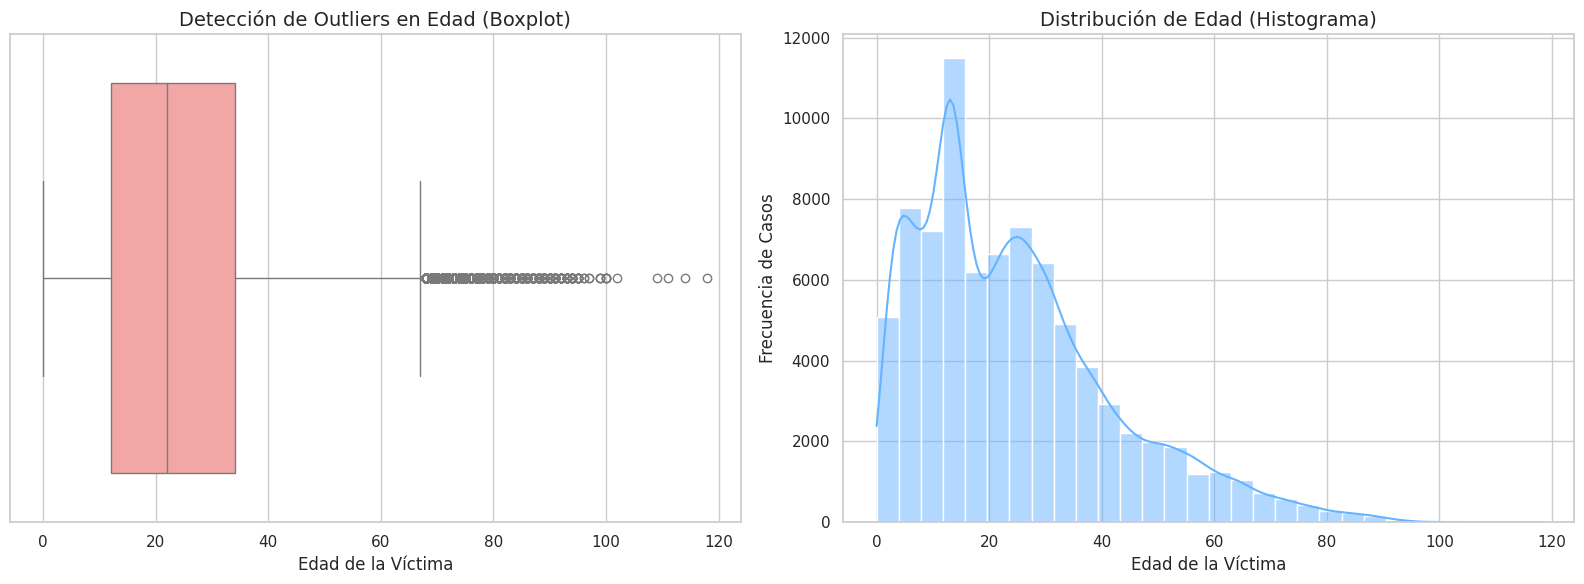

In [27]:
# visualización en Boxplot

sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos (Boxplot e Histograma)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. BOXPLOT
sns.boxplot(x=df_limpio['edad_'], color='#ff9999', ax=ax1)
ax1.set_title('Detección de Outliers en Edad (Boxplot)', fontsize=14)
ax1.set_xlabel('Edad de la Víctima')

# 2. HISTOGRAMA: Para ver la distribución y las "colas" largas
sns.histplot(df_limpio['edad_'], bins=30, kde=True, color='#66b3ff', ax=ax2)
ax2.set_title('Distribución de Edad (Histograma)', fontsize=14)
ax2.set_xlabel('Edad de la Víctima')
ax2.set_ylabel('Frecuencia de Casos')

plt.tight_layout()
plt.show()

se detectaron valores atitipicos se tratara con el metodo de winsorización

In [28]:
# Guardar versión original
df_limpio["edad_original"] = df_limpio["edad_"]
df_limpio["edad_"] = df_limpio['edad_'].clip(lower=0, upper=105)
print("===Se aplico metodo Winsorización===")

===Se aplico metodo Winsorización===


Metodo de winsorización ap´licado a la variables de años llegando el límte a 105 años

In [29]:
df_limpio["estrato_"].unique()

array([1, 2, 3, 6, 4, 5])

La variable estrato fue evaluada para detectar inconsistencias en su rango de codificación. Dado que presentó únicamente valores válidos entre 1 y 6, correspondientes a la clasificación normativa en Colombia, no se requirió tratamiento adicional ni aplicación de métodos de detección de valores atípicos.

# Estadisticas de las variables númericas

In [30]:
# Análisis de EDAD
print('=== Análisis de Tendencia Central - EDAD ===\n')

media_edad = df_limpio['edad_'].mean()
mediana_edad = df_limpio['edad_'].median()
moda_edad = df_limpio['edad_'].mode()[0] # Tomamos el primer valor si hay múltiples modas

print(f"Media: {media_edad:.2f} años")
print(f"Mediana: {mediana_edad:.2f} años")
print(f"Moda: {moda_edad:.2f} años")

# Interpretación automática
print("\n=== Interpretación ===")
if abs(media_edad - mediana_edad) < 1:
    print("Distribución aproximadamente simétrica")

elif media_edad > mediana_edad:
    print("La distribución de edad tiene asimetría positiva (media > mediana)")
    print("Esto significa que hay algunas victimas muy mayores que elevan el promedio.")

else:
    print("La distribución de edad tiene asimetría negativa (media < mediana)")
    print("Esto significa que hay algunas victimas muy mayores que bajan el promedio.")

=== Análisis de Tendencia Central - EDAD ===

Media: 24.78 años
Mediana: 22.00 años
Moda: 13.00 años

=== Interpretación ===
La distribución de edad tiene asimetría positiva (media > mediana)
Esto significa que hay algunas victimas muy mayores que elevan el promedio.


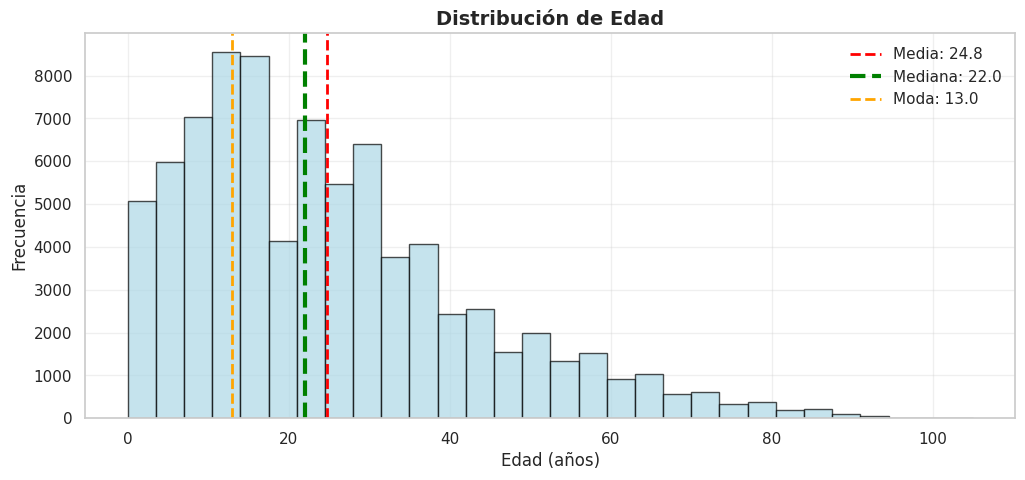


NOTA: Moda (13.0) y Mediana (22.0) están muy cerca, por lo que las líneas pueden superponerse en el gráfico


In [31]:
# Visualización edad

plt.figure(figsize=(12, 5))

plt.hist(df_limpio['edad_'], bins=30, color='lightblue', edgecolor='black', alpha=0.7) # Histograma de edad
plt.axvline(media_edad, color='red', linestyle='--', linewidth=2, label=f'Media: {media_edad:.1f}') # axvline dibuja una línea vertical
plt.axvline(mediana_edad, color='green', linestyle='--', linewidth=3, label=f'Mediana: {mediana_edad:.1f}')
plt.axvline(moda_edad, color='orange', linestyle='--', linewidth=2, label=f'Moda: {moda_edad:.1f}')

plt.title('Distribución de Edad', fontsize=14, fontweight='bold')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# La línea verde (mediana) puede estar oculta detrás de la línea naranja (moda) porque sus valores son muy similares
print(f"\nNOTA: Moda ({moda_edad:.1f}) y Mediana ({mediana_edad:.1f}) están muy cerca, por lo que las líneas pueden superponerse en el gráfico")


Medidas de Dispersión

Medidas principales:

Rango: Diferencia entre el valor máximo y mínimo
Cuartiles: Dividen los datos en 4 partes iguales
IQR (Rango Intercuartílico): Q3 - Q1 (contiene el 50% central de los datos)
Varianza: Promedio de las desviaciones cuadradas
Desviación Estándar: Raíz cuadrada de la varianza
Coeficiente de Variación: (Desv. Estándar / Media) × 100%

In [32]:
# Dispersión edad
print('=== Análisis de Dispersión - EDAD ===\n')

# Calcula el rango de la edad
rango_edad = df_limpio['edad_'].max() - df_limpio['edad_'].min()

# Calcula el primer cuartil (Q1)
# El Q1 corresponde al 25% de los datos están por debajo de este valor
q1_edad = df_limpio['edad_'].quantile(0.25)

# Calcula el tercer cuartil (Q3)
# El Q3 corrresponde al 75% de los datos están por debajo de este valor
q3_edad = df_limpio['edad_'].quantile(0.75)

# Calcula el rango intercuartílico (IQR), se calcula IQR = Q3 - Q1
# Mide la dispersión del 50% central de los datos, es decir, la variabilidad entre el cuartil 1 y el cuartil 3
iqr_edad = q3_edad - q1_edad

# Calcula la desviación estándar
std_edad = df_limpio['edad_'].std()

# Calcula el coeficiente de variación (CV)
# CV = (desviación estándar / media) * 100
# Es una medida de dispersión relativa expresada en porcentaje
# NOTA: media_edad debe estar previamente calculada
cv_edad = (std_edad / media_edad) * 100

# Mostramos los resultados

# Muestra el rango de edades
print(f"Rango: {rango_edad:.2f} años")

# Muestra el primer cuartil
print(f"Q1 (25%): {q1_edad:.2f} años")

# Muestra el tercer cuartil
print(f"Q3 (75%): {q3_edad:.2f} años")

# Muestra el rango intercuartílico
print(f"IQR: {iqr_edad:.2f} años")

# Muestra la desviación estándar
print(f"Desv. Estándar: {std_edad:.2f} años")

# Muestra el coeficiente de variación
print(f"Coef. Variación: {cv_edad:.2f}%")

# Interpretación automática del Coeficiente de Variación
print("\n--- Interpretación del Coeficiente de Variación ---")
if cv_edad < 15:
    print("Baja variabilidad: Las edades son bastante homogéneas")
elif cv_edad < 30:
    print("Variabilidad moderada: Hay cierta diversidad en las edades")
else:
    print("Alta variabilidad: Las edades son muy diversas")

=== Análisis de Dispersión - EDAD ===

Rango: 105.00 años
Q1 (25%): 12.00 años
Q3 (75%): 34.00 años
IQR: 22.00 años
Desv. Estándar: 17.76 años
Coef. Variación: 71.69%

--- Interpretación del Coeficiente de Variación ---
Alta variabilidad: Las edades son muy diversas


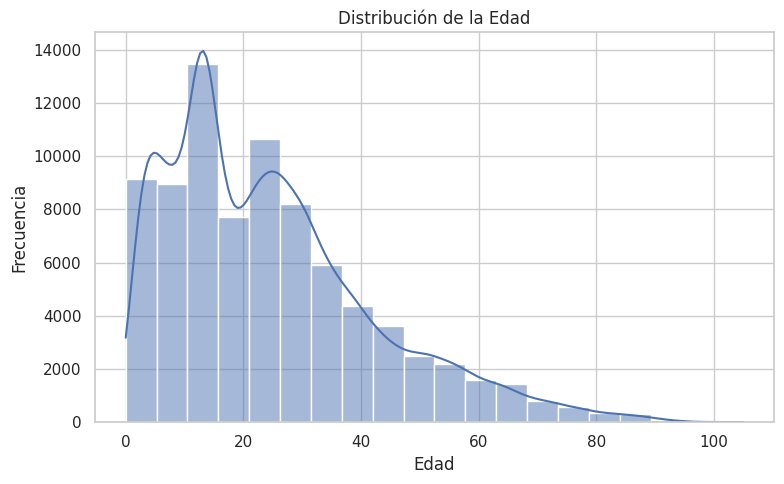

In [33]:
# Histograma de edad

plt.figure(figsize=(8,5))
sns.histplot(df_limpio["edad_"], bins=20, kde=True)

plt.title("Distribución de la Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [34]:
# Análisis de ESTRATO
print('=== Análisis de Tendencia Central - Estrato ===\n')

media_estrato = df_limpio['estrato_'].mean()
mediana_estrato = df_limpio['estrato_'].median()
moda_estrato = df_limpio['estrato_'].mode()[0] # Tomamos el primer valor si hay múltiples modas

print(f"Media: {media_estrato:.2f} estrato")
print(f"Mediana: {mediana_estrato:.2f} estrato")
print(f"Moda: {moda_estrato:.2f} estrato")

# Interpretación automática
print("\n=== Interpretación ===")
if abs(media_estrato - mediana_estrato) < 1:
    print("Distribución aproximadamente simétrica")

elif media_estrato > mediana_estrato:
    print("La distribución de edad tiene asimetría positiva (media > mediana)")
    print("Esto significa que hay algunos pasajeros muy mayores que elevan el promedio.")

else:
    print("La distribución de edad tiene asimetría negativa (media < mediana)")
    print("Esto significa que hay algunos pasajeros muy jóvenes que bajan el promedio.")

=== Análisis de Tendencia Central - Estrato ===

Media: 2.08 estrato
Mediana: 2.00 estrato
Moda: 2.00 estrato

=== Interpretación ===
Distribución aproximadamente simétrica


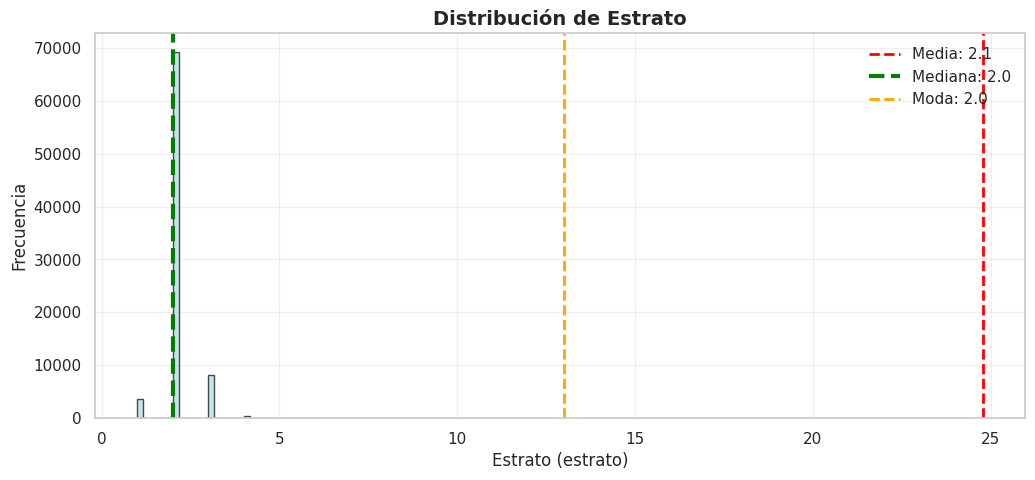


NOTA: Moda (2.0) y Mediana (2.0) están muy cerca, por lo que las líneas pueden superponerse en el gráfico


In [35]:
# Visualización estrato

plt.figure(figsize=(12, 5))

plt.hist(df_limpio['estrato_'], bins=30, color='lightblue', edgecolor='black', alpha=0.7) # Histograma de edad
plt.axvline(media_edad, color='red', linestyle='--', linewidth=2, label=f'Media: {media_estrato:.1f}') # axvline dibuja una línea vertical
plt.axvline(mediana_estrato, color='green', linestyle='--', linewidth=3, label=f'Mediana: {mediana_estrato:.1f}')
plt.axvline(moda_edad, color='orange', linestyle='--', linewidth=2, label=f'Moda: {moda_estrato:.1f}')

plt.title('Distribución de Estrato', fontsize=14, fontweight='bold')
plt.xlabel('Estrato (estrato)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# La línea verde (mediana) puede estar oculta detrás de la línea naranja (moda) porque sus valores son muy similares
print(f"\nNOTA: Moda ({moda_estrato:.1f}) y Mediana ({mediana_estrato:.1f}) están muy cerca, por lo que las líneas pueden superponerse en el gráfico")


In [36]:
# Dispersión estrato
print('=== Análisis de Dispersión - Estrato ===\n')

# Calcula el rango de estrato
rango_estrato = df_limpio['estrato_'].max() - df_limpio['estrato_'].min()

# Calcula el primer cuartil (Q1)
# El Q1 corresponde al 25% de los datos están por debajo de este valor
q1_estrato = df_limpio['estrato_'].quantile(0.25)

# Calcula el tercer cuartil (Q3)
# El Q3 corrresponde al 75% de los datos están por debajo de este valor
q3_estrato = df_limpio['estrato_'].quantile(0.75)

# Calcula el rango intercuartílico (IQR), se calcula IQR = Q3 - Q1
# Mide la dispersión del 50% central de los datos, es decir, la variabilidad entre el cuartil 1 y el cuartil 3
iqr_estrato = q3_estrato - q1_estrato

# Calcula la desviación estándar
std_estrato = df_limpio['estrato_'].std()

# Calcula el coeficiente de variación (CV)
# CV = (desviación estándar / media) * 100
# Es una medida de dispersión relativa expresada en porcentaje
# NOTA: media_edad debe estar previamente calculada
cv_estrato = (std_estrato / media_estrato) * 100

# Mostramos los resultados

# Muestra el rango de edades
print(f"Rango: {rango_estrato:.2f} estrato")

# Muestra el primer cuartil
print(f"Q1 (25%): {q1_estrato:.2f} estrato")

# Muestra el tercer cuartil
print(f"Q3 (75%): {q3_estrato:.2f} estrato")

# Muestra el rango intercuartílico
print(f"IQR: {iqr_estrato:.2f} estrato")

# Muestra la desviación estándar
print(f"Desv. Estándar: {std_estrato:.2f} estrato")

# Muestra el coeficiente de variación
print(f"Coef. Variación: {cv_edad:.2f}%")

# Interpretación automática del Coeficiente de Variación
print("\n--- Interpretación del Coeficiente de Variación ---")
if cv_edad < 15:
    print("Baja variabilidad: Los estratos son bastante homogéneas")
elif cv_edad < 30:
    print("Variabilidad moderada: Hay cierta diversidad en los estratos")
else:
    print("Alta variabilidad: Los estratos son muy diversos")

=== Análisis de Dispersión - Estrato ===

Rango: 5.00 estrato
Q1 (25%): 2.00 estrato
Q3 (75%): 2.00 estrato
IQR: 0.00 estrato
Desv. Estándar: 0.44 estrato
Coef. Variación: 71.69%

--- Interpretación del Coeficiente de Variación ---
Alta variabilidad: Los estratos son muy diversos


# Tablas de Frecuencia (Variables Categóricas) naturaleza_nom

sexo_;
ciclo_vital;
nombre_comuna;
r_fam_vic_nom;
orient_sex_nom;
ident_gene_nom

In [37]:
# variable sexo

def tabla_frecuencia(variable):
    freq_abs = df_limpio["sexo_"].value_counts()
    freq_rel = df_limpio["sexo_"].value_counts(normalize=True) * 100

    tabla = pd.DataFrame({
        "Frecuencia Absoluta": freq_abs,
        "Frecuencia Relativa (%)": freq_rel.round(2)
    })

    return tabla

print(tabla_frecuencia("sexo_"))

       Frecuencia Absoluta  Frecuencia Relativa (%)
sexo_                                              
F                    66132                    80.83
M                    15688                    19.17


La mayoria de casos reportados de violencia de genero corresponden al sexo femenino con 80.83%

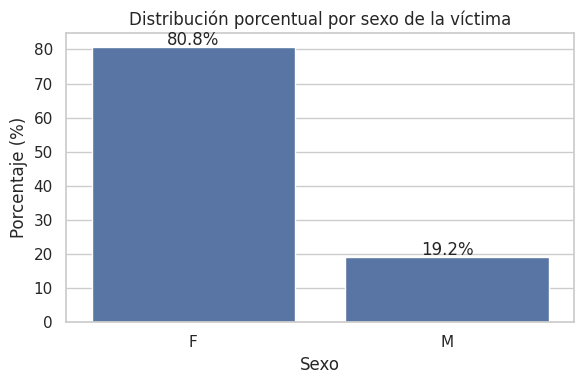

In [38]:
# Calcular frecuencias relativas variable sexo

sexo_porcentaje = df_limpio["sexo_"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
sns.barplot(x=sexo_porcentaje.index, y=sexo_porcentaje.values)

plt.title("Distribución porcentual por sexo de la víctima")
plt.xlabel("Sexo")
plt.ylabel("Porcentaje (%)")

# Agregar etiquetas de porcentaje encima de cada barra
for i, v in enumerate(sexo_porcentaje.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

In [39]:
# Nombre comuna

def tabla_frecuencia(variable):
    freq_abs = df_limpio["nombre_comuna"].value_counts()
    freq_rel = df_limpio["nombre_comuna"].value_counts(normalize=True) * 100

    tabla = pd.DataFrame({
        "Frecuencia Absoluta": freq_abs,
        "Frecuencia Relativa (%)": freq_rel.round(2)
    })

    return tabla

print(tabla_frecuencia("nombre_comuna"))

                                          Frecuencia Absoluta  Frecuencia Relativa (%)
nombre_comuna                                                                         
SIN INFORMACIÓN                                          7664                     9.37
03 MANRIQUE                                              6943                     8.49
08 VILLA HERMOSA                                         6099                     7.45
07 ROBLEDO                                               6034                     7.37
06 DOCE DE OCTUBRE                                       5588                     6.83
01 POPULAR                                               5514                     6.74
13 SAN JAVIER                                            5192                     6.35
04 ARANJUEZ                                              5050                     6.17
16 BELÉN                                                 4747                     5.80
09 BUENOS AIRES                            

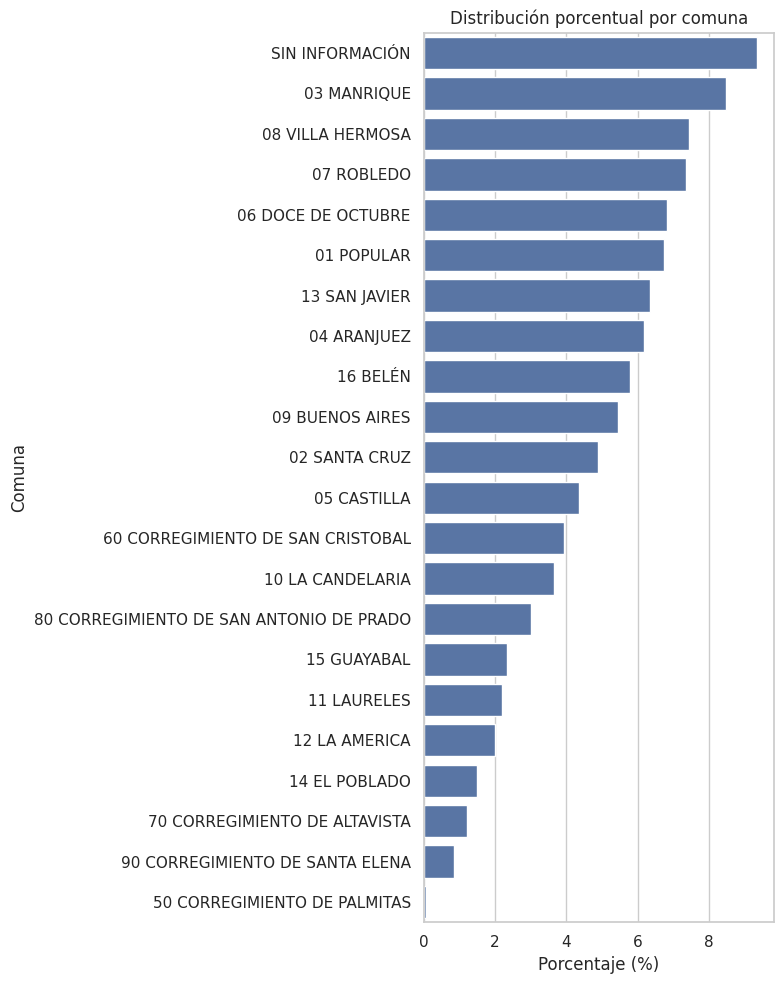

In [40]:
# Grafico de frecuencia varaible nombre comuna

comuna_porcentaje = df_limpio["nombre_comuna"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,10))
sns.barplot(x=comuna_porcentaje.values, y=comuna_porcentaje.index)

plt.title("Distribución porcentual por comuna")
plt.xlabel("Porcentaje (%)")
plt.ylabel("Comuna")

plt.tight_layout()
plt.show()

Se identificó que el 9.37% de los registros no cuentan con información de comuna. Estos casos fueron considerados dentro del análisis descriptivo general; sin embargo, no se van a tener en cuenta en el análisis territorial y del proceso de clustering, dado que no es posible asignarlos geográficamente.

In [41]:
# variable r_fam_vic_nom

def tabla_frecuencia(variable):
    freq_abs = df_limpio["r_fam_vic_nom"].value_counts()
    freq_rel = df_limpio["r_fam_vic_nom"].value_counts(normalize=True) * 100

    tabla = pd.DataFrame({
        "Frecuencia Absoluta": freq_abs,
        "Frecuencia Relativa (%)": freq_rel.round(2)
    })

    return tabla

print(tabla_frecuencia("r_fam_vic_nom"))


                      Frecuencia Absoluta  Frecuencia Relativa (%)
r_fam_vic_nom                                                     
desconocido                         21398                    26.15
amigo/a                             16143                    19.73
conocido/a                          13831                    16.90
vecino/a                             7252                     8.86
tio/a                                7188                     8.79
sin dato                             6683                     8.17
ex-novio/a                           2935                     3.59
ex-pareja                            1596                     1.95
pareja                               1378                     1.68
padre/Madre                          1011                     1.24
otro familiar                         503                     0.61
sobrino/a                             431                     0.53
madrastra                             381                     

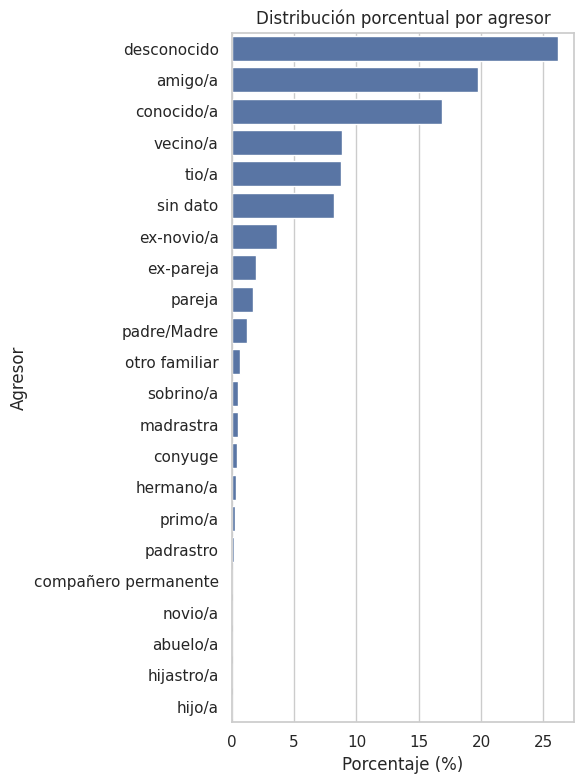

In [42]:
# Persona agresora

agresor_porcentaje = df_limpio["r_fam_vic_nom"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,8))
sns.barplot(x=agresor_porcentaje.values, y=agresor_porcentaje.index)

plt.title("Distribución porcentual por agresor")
plt.xlabel("Porcentaje (%)")
plt.ylabel("Agresor")

plt.tight_layout()
plt.show()

Se observa que el 34.33% de los registros no permiten identificar claramente la relación entre víctima y agresor (desconocido o sin dato). Pero dentro de los casos con información disponible, predomina el entorno social cercano (amigos, conocidos y vecinos), lo cual sugiere que la violencia se presenta principalmente en círculos relacionales próximos a la víctima.

In [43]:
# Nombre orientación sexual

def tabla_frecuencia(variable):
    freq_abs = df_limpio["orient_sex_nom"].value_counts()
    freq_rel = df_limpio["orient_sex_nom"].value_counts(normalize=True) * 100

    tabla = pd.DataFrame({
        "Frecuencia Absoluta": freq_abs,
        "Frecuencia Relativa (%)": freq_rel.round(2)
    })

    return tabla

print(tabla_frecuencia("orient_sex_nom"))

                Frecuencia Absoluta  Frecuencia Relativa (%)
orient_sex_nom                                              
indeterminado                 58963                    72.06
sin dato                      14856                    18.16
otro                           6059                     7.41
homosexual                      966                     1.18
heterosexual                    954                     1.17
bisexual                         22                     0.03


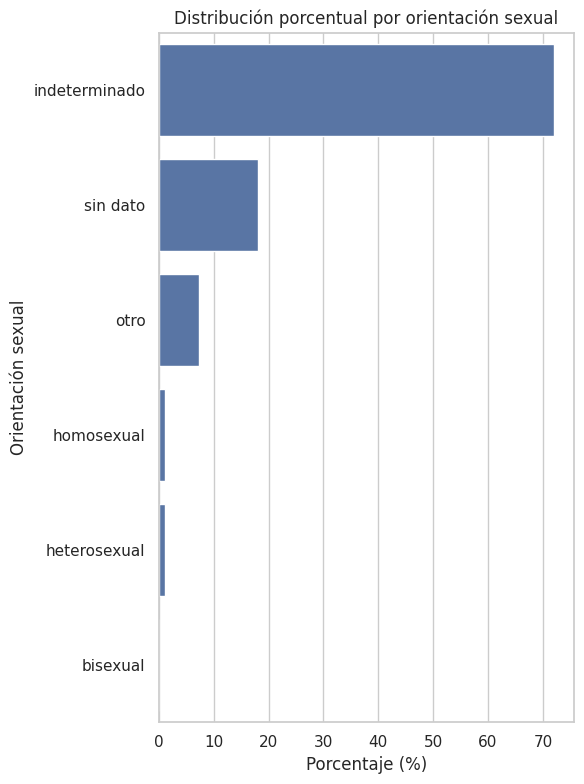

In [44]:
# Grafico Orientación sexual


orientacion_sexual = df_limpio["orient_sex_nom"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,8))
sns.barplot(x=orientacion_sexual.values, y=orientacion_sexual.index)

plt.title("Distribución porcentual por orientación sexual")
plt.xlabel("Porcentaje (%)")
plt.ylabel("Orientación sexual")

plt.tight_layout()
plt.show()

La variable orientación sexual presenta una distribución altamente concentrada en categorías no informativas, donde el 72.07% de los registros se clasifican como “indeterminado” y el 18.15% como “sin dato”. En conjunto, más del 90% de los registros no contienen información específica, lo que limita significativamente su utilidad analítica.

 La calidad informativa de la variable es baja. Las categorías específicas (heterosexual, homosexual y bisexual) presentan una representación inferior al 2%, evidenciando un fuerte desbalance de clases.

Desde una perspectiva metodológica, se recomienda evaluar la pertinencia de incluir esta variable en modelos analíticos o considerar su recategorización. Asimismo, dado que corresponde a un atributo sensible, su tratamiento debe cumplir principios éticos y de protección de datos.

In [45]:
#  variable CICLO VITAL

def tabla_frecuencia(variable):
    freq_abs = df_limpio["ciclo_vital"].value_counts()
    freq_rel = df_limpio["ciclo_vital"].value_counts(normalize=True) * 100

    tabla = pd.DataFrame({
        "Frecuencia Absoluta": freq_abs,
        "Frecuencia Relativa (%)": freq_rel.round(2)
    })

    return tabla

print(tabla_frecuencia("ciclo_vital"))

               Frecuencia Absoluta  Frecuencia Relativa (%)
ciclo_vital                                                
Adultez                      25333                    30.96
Infancia                     20065                    24.52
Juventud                     16590                    20.28
Adolescencia                 15065                    18.41
Persona Mayor                 4764                     5.82


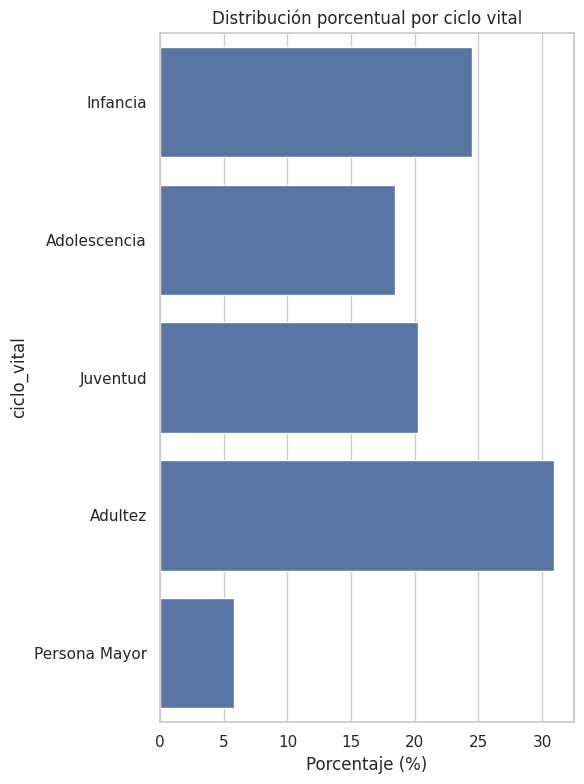

In [46]:
# Grafico CICLO VITAL


ciclo_vital = df_limpio["ciclo_vital"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,8))
sns.barplot(x=ciclo_vital.values, y=ciclo_vital.index)

plt.title("Distribución porcentual por ciclo vital")
plt.xlabel("Porcentaje (%)")
plt.ylabel("ciclo_vital")

plt.tight_layout()
plt.show()

La variable ciclo vital presenta una distribución relativamente equilibrada entre las categorías, con mayor concentración en la etapa de adultez (30.96%), seguida de infancia (24.53%) y juventud (20.28%). La categoría persona mayor representa el 5.82% del total, siendo la menos representada.

A diferencia de otras variables con fuerte concentración en categorías no informativas, esta variable muestra una estructura poblacional adecuada para análisis comparativos y modelamiento estadístico.

La distribución sugiere que el fenómeno analizado tiene mayor presencia en etapas productivas del ciclo de vida, lo que podría estar asociado a dinámicas sociales o demográficas propias del contexto del estudio.

In [47]:
# Variable ident_gene_nom

def tabla_frecuencia(variable):
    freq_abs = df_limpio["ident_gene_nom"].value_counts()
    freq_rel = df_limpio["ident_gene_nom"].value_counts(normalize=True) * 100

    tabla = pd.DataFrame({
        "Frecuencia Absoluta": freq_abs,
        "Frecuencia Relativa (%)": freq_rel.round(2)
    })

    return tabla

print(tabla_frecuencia("ident_gene_nom"))

                Frecuencia Absoluta  Frecuencia Relativa (%)
ident_gene_nom                                              
femenino                      55367                    67.67
sin dato                      13421                    16.40
masculino                     12927                    15.80
transgénero                      87                     0.11
otro                             18                     0.02


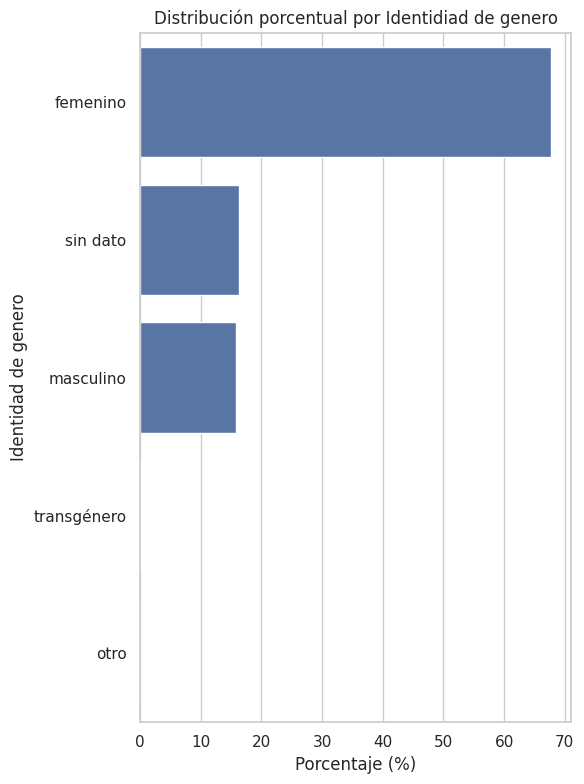

In [48]:
# Grafico Identidad de genero


ident_gene_nom = df_limpio["ident_gene_nom"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,8))
sns.barplot(x=ident_gene_nom.values, y=ident_gene_nom.index)

plt.title("Distribución porcentual por Identidiad de genero")
plt.xlabel("Porcentaje (%)")
plt.ylabel("Identidad de genero")

plt.tight_layout()
plt.show()

Con un 67.67%, el género femenino representa la mayoría de los casos registrados. No obstante, preocupa el volumen de casos sin clasificar, lo cual sugiere una oportunidad de mejora en los procesos de reporte y una posible subestimación de las cifras reales debido a la falta de datos

# Analisis series de tiempo



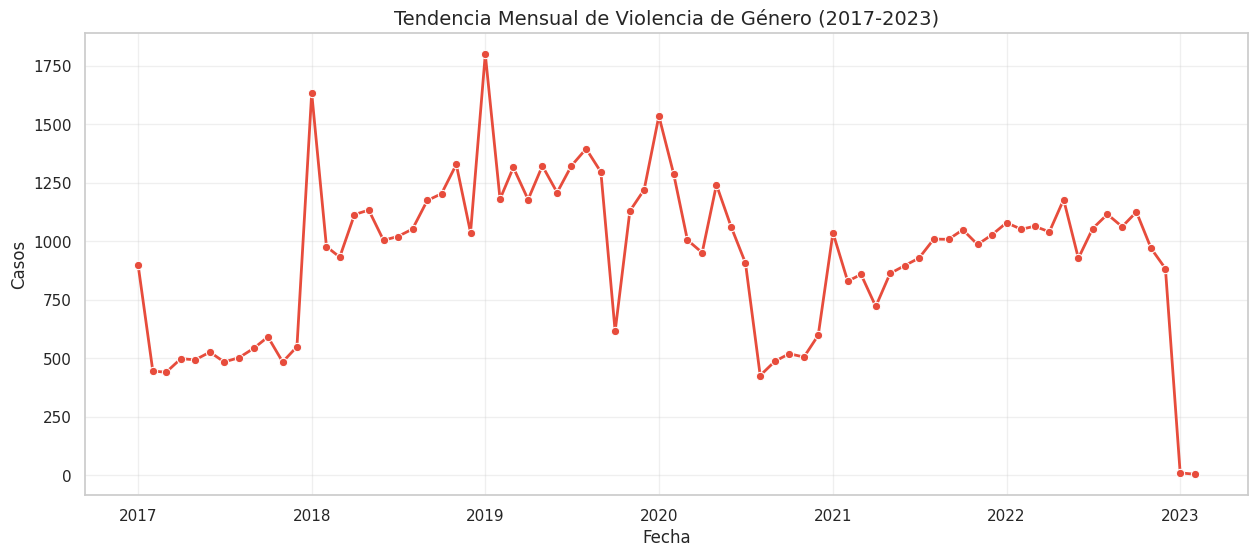

In [49]:
# Filtro periodo válido 2017-2023
df_ts = df_limpio[df_limpio['estado_hecho_final'] == "Fecha válida"].copy()

# Agrución por Año y Mes
serie_mensual = df_ts.groupby(['Anio', 'Mes']).size().reset_index(name='Casos')

# Serie mensual
serie_mensual['Fecha'] = pd.to_datetime({
    'year': serie_mensual['Anio'],
    'month': serie_mensual['Mes'],
    'day': 1
})

serie_mensual = serie_mensual.sort_values('Fecha')

# Grafica
plt.figure(figsize=(15, 6))
sns.lineplot(data=serie_mensual, x='Fecha', y='Casos', color='#e74c3c', linewidth=2, marker='o')
plt.title('Tendencia Mensual de Violencia de Género (2017-2023)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

La tendencia es en aumento de los casos en el año 2019 es el pico de reporte de casos, despues empieza a bajar hasta el año 2022

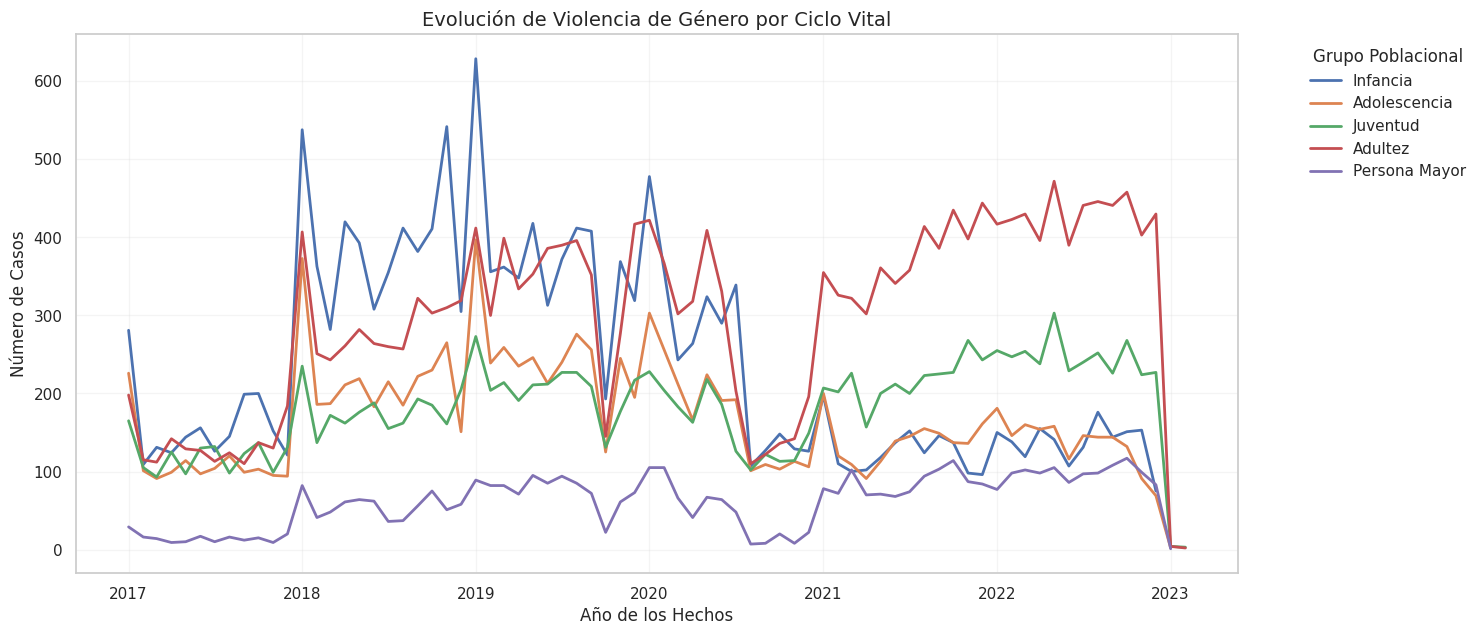

In [50]:
# Agrupamos por fecha y ciclo vital
# Usamos resample('MS') que significa "Month Start" para agrupar por mes automáticamente
df_ciclo_temp = df_ts.set_index('fec_hecho').groupby('ciclo_vital').resample('MS').size().reset_index(name='Casos')

plt.figure(figsize=(15, 7))
sns.lineplot(data=df_ciclo_temp, x='fec_hecho', y='Casos', hue='ciclo_vital', linewidth=2)
plt.title('Evolución de Violencia de Género por Ciclo Vital', fontsize=14)
plt.ylabel('Número de Casos')
plt.xlabel('Año de los Hechos')
plt.legend(title='Grupo Poblacional', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.show()

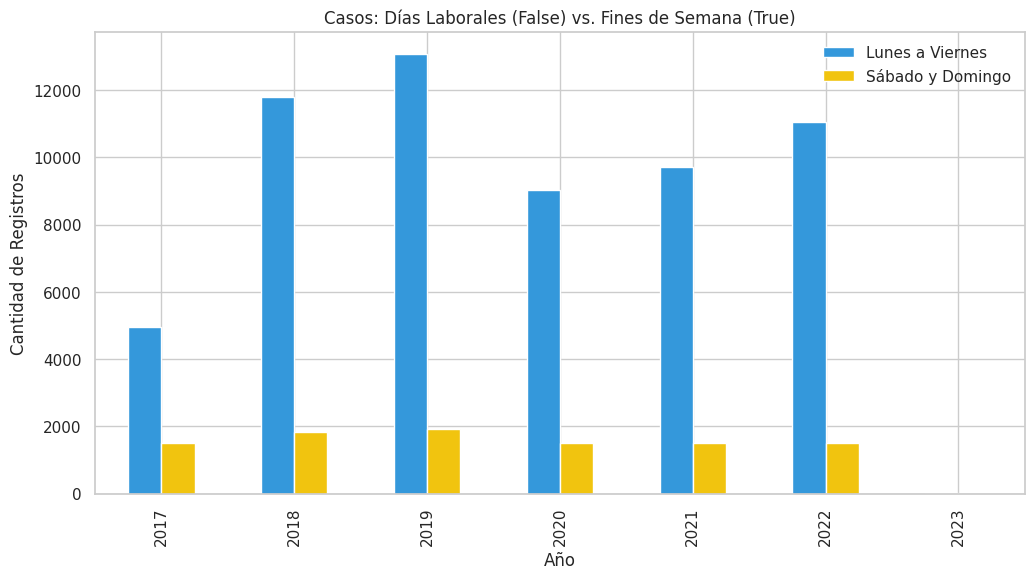

In [51]:
# Comparación de promedios: Fin de semana vs Día laboral
comparativo_semana = df_ts.groupby(['Anio', 'es_fin_semana']).size().unstack()
comparativo_semana.plot(kind='bar', stacked=False, figsize=(12, 6), color=['#3498db', '#f1c40f'])

plt.title('Casos: Días Laborales (False) vs. Fines de Semana (True)')
plt.ylabel('Cantidad de Registros')
plt.xlabel('Año')
plt.legend(['Lunes a Viernes', 'Sábado y Domingo'])
plt.show()

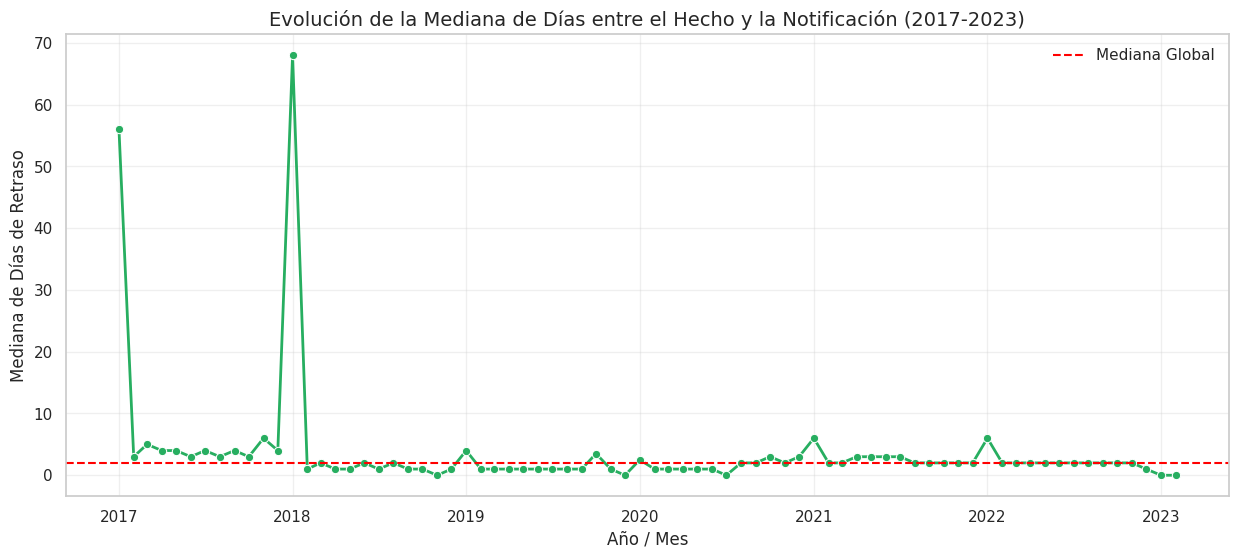

In [52]:
# 1. Agrupar por mes y calcular la mediana del retraso (dias_diferencia)
serie_retraso = df_ts.groupby(['Anio', 'Mes'])['dias_diferencia'].median().reset_index()

# 2. Crear la columna de fecha para el eje X
serie_retraso['Fecha'] = pd.to_datetime({
    'year': serie_retraso['Anio'],
    'month': serie_retraso['Mes'],
    'day': 1
})

# 3. Graficar la evolución de la eficiencia de reporte
plt.figure(figsize=(15, 6))
sns.lineplot(data=serie_retraso, x='Fecha', y='dias_diferencia', marker='o', color='#27ae60', linewidth=2)

plt.title('Evolución de la Mediana de Días entre el Hecho y la Notificación (2017-2023)', fontsize=14)
plt.ylabel('Mediana de Días de Retraso')
plt.xlabel('Año / Mes')
plt.grid(True, alpha=0.3)
plt.axhline(serie_retraso['dias_diferencia'].median(), color='red', linestyle='--', label='Mediana Global')
plt.legend()
plt.show()

Para el análisis de la brecha temporal entre el hecho y la notificación (dias_diferencia), se seleccionó la mediana como medida de tendencia central en lugar del promedio aritmético. Esta decisión obedece a que los datos de Sivigila presentan una distribución con asimetría positiva (sesgada a la derecha), donde una minoría de registros reporta retrasos extremos (meses o años) que inflarían el promedio de manera artificial.

El uso de la mediana permite obtener un indicador de 'oportunidad' más fiel a la experiencia de la mayoría de las víctimas, representando el punto en el que el 50% de los casos ya han sido notificados, garantizando así que el análisis de eficiencia del sistema de salud no se vea distorsionado por errores de digitación o casos excepcionales de notificación tardía.

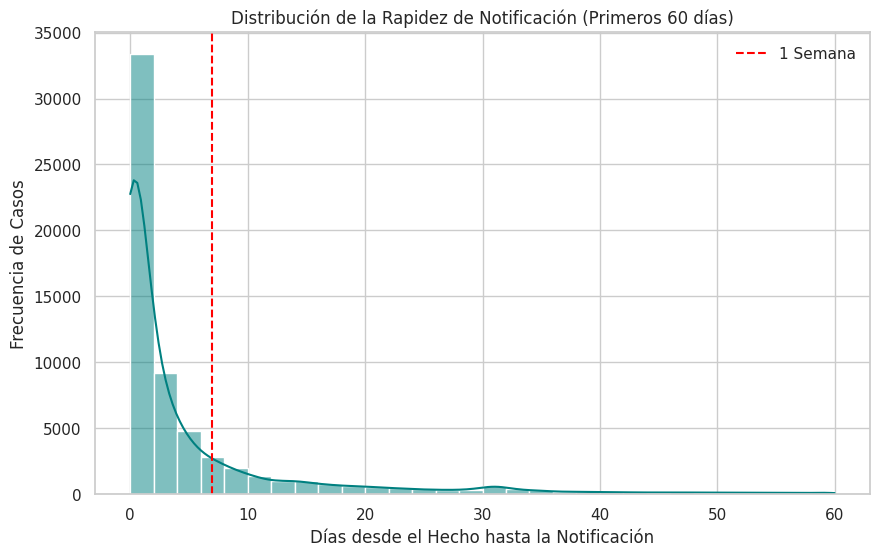

In [53]:
plt.figure(figsize=(10, 6))
# Filtramos a menos de 60 días para ver el detalle (la gran mayoría cae aquí)
sns.histplot(df_ts[df_ts['dias_diferencia'] <= 60]['dias_diferencia'], bins=30, kde=True, color='teal')

plt.title('Distribución de la Rapidez de Notificación (Primeros 60 días)')
plt.xlabel('Días desde el Hecho hasta la Notificación')
plt.ylabel('Frecuencia de Casos')
plt.axvline(7, color='red', linestyle='--', label='1 Semana')
plt.legend()
plt.show()

# Analisis bivariados

In [54]:
# Comuna y tipología (naturaleza)

tabla_porcentual = pd.crosstab(
    df_limpio["nombre_comuna"],
    df_limpio["naturaleza_nom"],
    normalize="index"
) * 100

print("=== Porcentaje por Comuna ===")
print(tabla_porcentual.round(2))

=== Porcentaje por Comuna ===
naturaleza_nom                            fisica  no especificado en ficha  psicologica  sexual
nombre_comuna                                                                                  
01 POPULAR                                 44.96                     34.35        10.86    9.83
02 SANTA CRUZ                              43.54                     31.84         9.97   14.65
03 MANRIQUE                                42.43                     29.90        12.72   14.95
04 ARANJUEZ                                43.92                     30.99        15.39    9.70
05 CASTILLA                                46.25                     30.78        14.59    8.38
06 DOCE DE OCTUBRE                         49.39                     32.52        10.84    7.25
07 ROBLEDO                                 43.87                     32.68        10.23   13.23
08 VILLA HERMOSA                           46.81                     32.89         7.87   12.43
09 BUENOS 

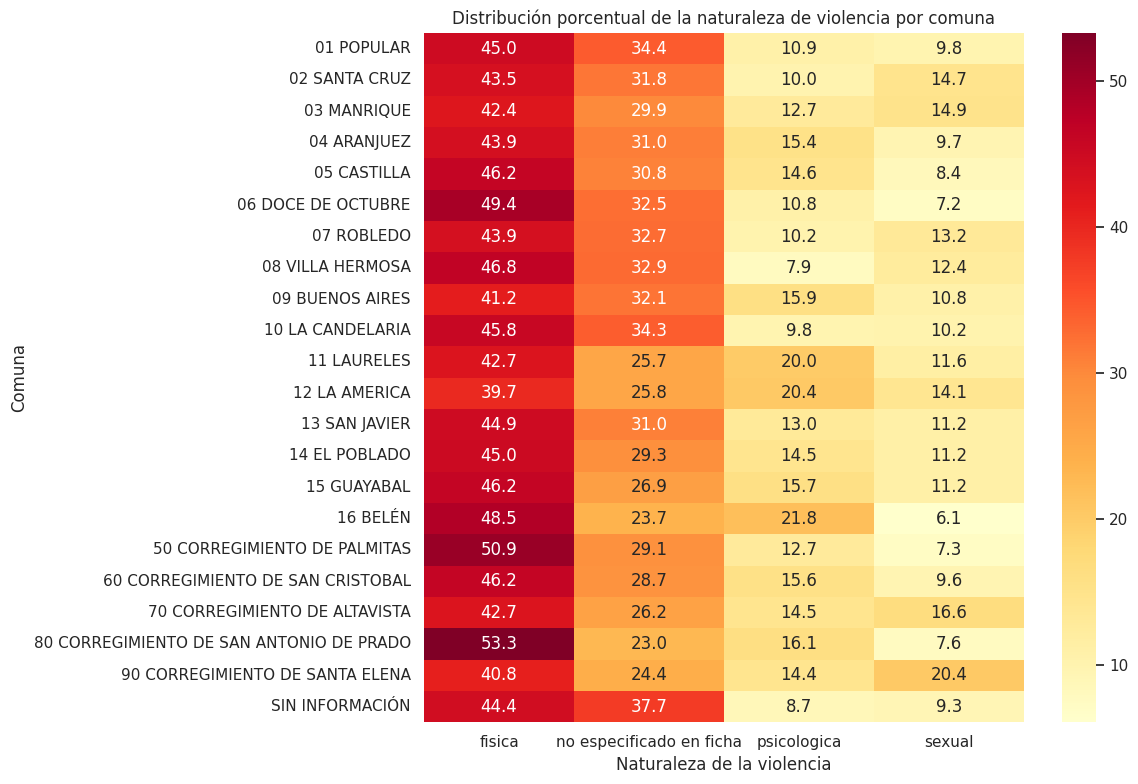

In [55]:
# Grafica

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(tabla_porcentual.round(2),
            annot=True,
            fmt=".1f",
            cmap="YlOrRd")

plt.title("Distribución porcentual de la naturaleza de violencia por comuna")
plt.ylabel("Comuna")
plt.xlabel("Naturaleza de la violencia")

plt.tight_layout()
plt.show()

Análisis territorial de la tipificación de la violencia

El análisis porcentual por comuna evidencia variaciones en la distribución de las modalidades de violencia. Aunque la violencia física predomina en la mayoría de las comunas, su proporción oscila entre 39.70% y 53.28%, lo que indica diferencias territoriales relevantes.

Se identifican comunas con mayor predominio de violencia psicológica (Laureles, La América y Belén) y otras con mayor incidencia relativa de violencia sexual (Santa Elena y Altavista). Estas diferencias sugieren que la tipificación de la violencia no se distribuye de manera homogénea en el territorio, evidenciando una influencia del contexto geográfico.

Los resultados preliminares permiten identificar posibles grupos de comunas con perfiles similares, lo cual respalda la pertinencia de aplicar técnicas de clustering para agrupar territorios según su patrón de violencia predominante.

In [56]:
# Medidicon de la varianza comuna y naturaleza

tabla_porcentual.std()

,0
naturaleza_nom,
fisica,3.273154
no especificado en ficha,3.835281
psicologica,3.727603
sexual,3.398380


La desviación estándar de las modalidades de violencia entre comunas oscila entre 3.27 y 3.83 puntos porcentuales, lo que evidencia una variabilidad territorial moderada. La violencia psicológica y la categoría “no especificado” presentan mayor heterogeneidad, mientras que la violencia física muestra mayor estabilidad relativa entre comunas. Estos resultados indican que, aunque existe un patrón general común en la ciudad, se observan diferencias territoriales suficientes para justificar la aplicación de técnicas de agrupamiento con el fin de identificar clústeres de comunas con perfiles similares de violencia.

In [57]:
# Estrato promedio por comuna

estrato_promedio = df_limpio.groupby("nombre_comuna")["estrato_"].mean()

print(estrato_promedio.round(2))

nombre_comuna
01 POPULAR                                  1.97
02 SANTA CRUZ                               2.02
03 MANRIQUE                                 2.05
04 ARANJUEZ                                 2.06
05 CASTILLA                                 2.04
06 DOCE DE OCTUBRE                          2.03
07 ROBLEDO                                  2.06
08 VILLA HERMOSA                            2.11
09 BUENOS AIRES                             2.17
10 LA CANDELARIA                            2.12
11 LAURELES                                 2.19
12 LA AMERICA                               2.17
13 SAN JAVIER                               2.04
14 EL POBLADO                               2.34
15 GUAYABAL                                 2.18
16 BELÉN                                    2.13
50 CORREGIMIENTO DE PALMITAS                1.95
60 CORREGIMIENTO DE SAN CRISTOBAL           2.04
70 CORREGIMIENTO DE ALTAVISTA               2.06
80 CORREGIMIENTO DE SAN ANTONIO DE PRADO    2.07
90 COR

In [58]:
tabla_estrato = pd.crosstab(
    df_limpio["nombre_comuna"],
    df_limpio["estrato_"],   # usa el nombre exacto de tu columna
    normalize="index"
) * 100

print(tabla_estrato.round(2))

estrato_                                      1      2      3     4     5     6
nombre_comuna                                                                  
01 POPULAR                                 8.80  85.60   5.48  0.09  0.00  0.04
02 SANTA CRUZ                              2.82  92.33   4.70  0.02  0.00  0.12
03 MANRIQUE                                3.27  88.65   7.89  0.07  0.04  0.07
04 ARANJUEZ                                3.05  88.46   8.40  0.06  0.00  0.04
05 CASTILLA                                5.60  84.96   9.19  0.08  0.03  0.14
06 DOCE DE OCTUBRE                         5.37  86.88   7.53  0.13  0.00  0.09
07 ROBLEDO                                 4.99  84.54   9.99  0.40  0.02  0.07
08 VILLA HERMOSA                           3.02  83.44  13.28  0.16  0.02  0.08
09 BUENOS AIRES                            1.93  79.76  17.84  0.36  0.11  0.00
10 LA CANDELARIA                           3.11  82.80  12.91  0.90  0.23  0.03
11 LAURELES                             

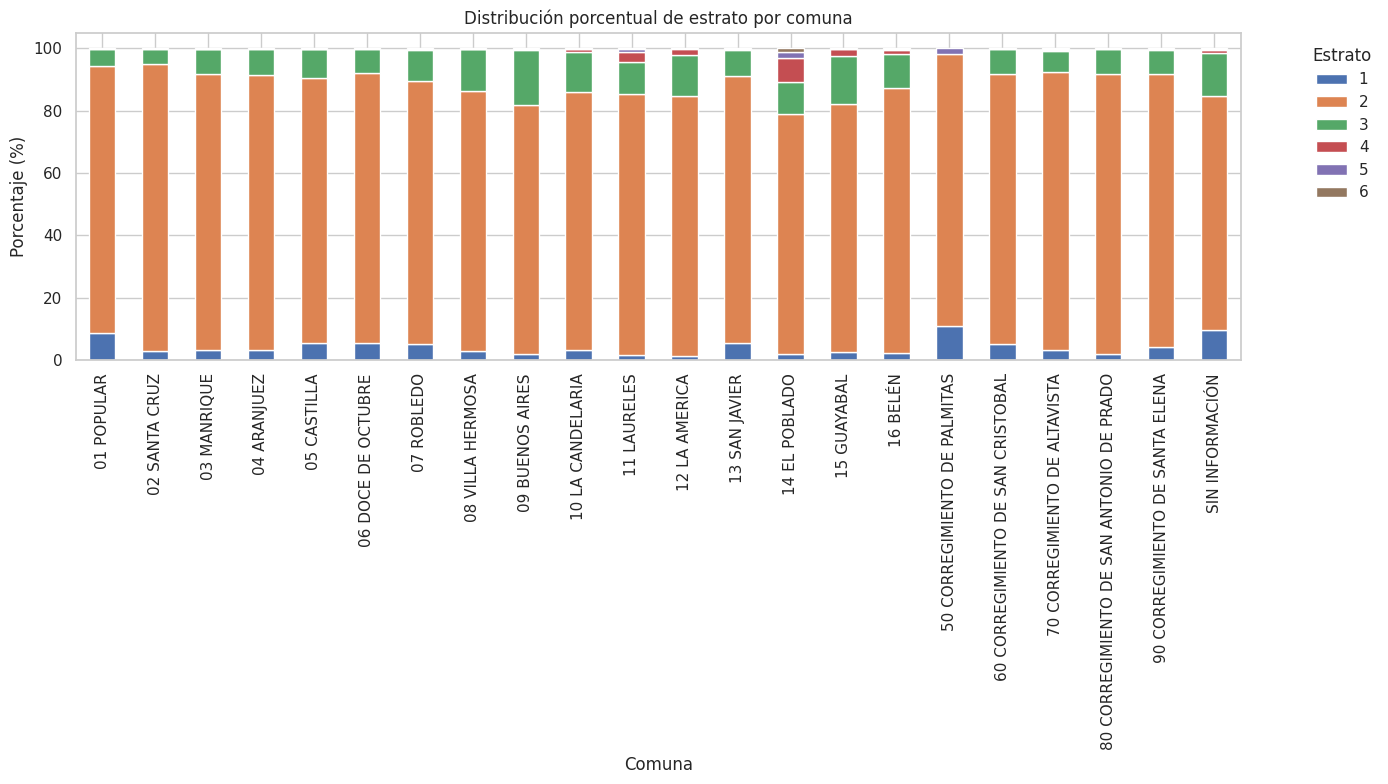

In [59]:
# Grafico nombre de comuna y estrato


import matplotlib.pyplot as plt

# Crear gráfico
tabla_estrato.plot(
    kind="bar",
    stacked=True,
    figsize=(14,8)
)

plt.title("Distribución porcentual de estrato por comuna")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Comuna")
plt.legend(title="Estrato", bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


El análisis de la distribución porcentual del estrato socioeconómico por comuna evidencia una fuerte concentración en estrato 2 en toda la ciudad. No obstante, se observan diferencias relevantes en la proporción de estrato 1 en comunas periféricas y en la presencia de estratos 3 y 4 en zonas centrales como El Poblado, Laureles y La América. Estas diferencias estructurales permiten contextualizar los patrones de tipificación de la violencia y sugieren que el componente socioeconómico podría influir parcialmente en la configuración territorial del fenómeno.

In [60]:
# Matriz de correlación

# Selección solo columnas numéricas

df_corr = df_limpio.select_dtypes(include=["int64", "float64"])

print("Columnas usadas en la correlación:")
print(df_corr.columns)

Columnas usadas en la correlación:
Index(['edad_', 'estrato_', 'codigo_comuna', 'orient_sex', 'ident_gene', 'naturaleza', 'r_fam_vic', 'anio_hecho_orig', 'dias_diferencia', 'Semestre', 'edad_original'], dtype='object')


# Matriz de correlación

In [61]:
# union de las tablas % violencia + estrato

matriz_comunas = tabla_porcentual.join(tabla_estrato)

print("=== Matriz final por comuna ===")
print(matriz_comunas.round(2))

=== Matriz final por comuna ===
                                          fisica  no especificado en ficha  psicologica  sexual      1      2      3     4     5     6
nombre_comuna                                                                                                                         
01 POPULAR                                 44.96                     34.35        10.86    9.83   8.80  85.60   5.48  0.09  0.00  0.04
02 SANTA CRUZ                              43.54                     31.84         9.97   14.65   2.82  92.33   4.70  0.02  0.00  0.12
03 MANRIQUE                                42.43                     29.90        12.72   14.95   3.27  88.65   7.89  0.07  0.04  0.07
04 ARANJUEZ                                43.92                     30.99        15.39    9.70   3.05  88.46   8.40  0.06  0.00  0.04
05 CASTILLA                                46.25                     30.78        14.59    8.38   5.60  84.96   9.19  0.08  0.03  0.14
06 DOCE DE OCTUBRE     

In [62]:

# Calcular la matriz de correlacion

matriz_correlacion = matriz_comunas.corr(method="pearson")

# Mostrar resultados
print("Matriz de correlación:")
print(matriz_correlacion.round(3))

Matriz de correlación:
                          fisica  no especificado en ficha  psicologica  sexual      1      2      3      4      5      6
fisica                     1.000                    -0.093       -0.113  -0.734  0.276  0.164 -0.331 -0.112  0.143 -0.048
no especificado en ficha  -0.093                     1.000       -0.793  -0.169  0.511 -0.343  0.137 -0.203 -0.188  0.018
psicologica               -0.113                    -0.793        1.000  -0.093 -0.501  0.026  0.146  0.314  0.205 -0.016
sexual                    -0.734                    -0.169       -0.093   1.000 -0.294  0.202  0.003 -0.007 -0.149  0.043
1                          0.276                     0.511       -0.501  -0.294  1.000 -0.065 -0.461 -0.358  0.140 -0.139
2                          0.164                    -0.343        0.026   0.202 -0.065  1.000 -0.715 -0.562 -0.276 -0.456
3                         -0.331                     0.137        0.146   0.003 -0.461 -0.715  1.000  0.260 -0.261  0.057
4

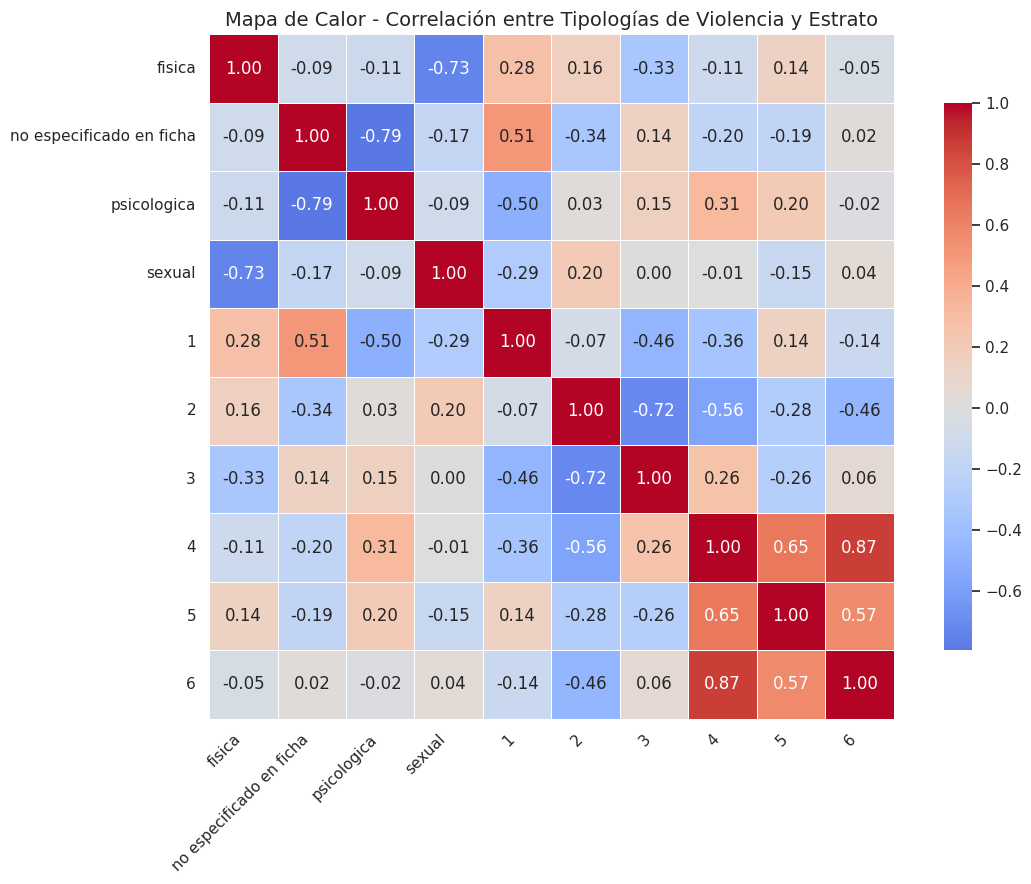

In [63]:
# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(12, 9))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Mapa de Calor - Correlación entre Tipologías de Violencia y Estrato", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

La matriz de correlación permitió identificar relaciones lineales entre las tipologías de violencia y la distribución socioeconómica por estrato en las comunas de Medellín.

Se observan correlaciones negativas fuertes entre algunas modalidades, especialmente entre violencia física y sexual (r ≈ -0.73), lo que indica que las comunas donde predomina un tipo tienden a presentar menor proporción del otro. Asimismo, la violencia psicológica muestra una relación negativa significativa con los registros no especificados (r ≈ -0.79), lo que sugiere que una mayor precisión en la clasificación reduce los casos sin tipificación clara.

En relación con los estratos socioeconómicos, se evidencian correlaciones negativas entre estratos bajos y medios, y correlaciones positivas altas entre estratos medios-altos (4, 5 y 6), reflejando patrones estructurales en la composición territorial.

En conjunto, estos resultados muestran que existen asociaciones sistemáticas entre tipo de violencia y contexto socioeconómico, El mapa de calor muestra que algunos tipos de violencia tienden a comportarse de forma opuesta entre comunas. Además, se evidencian patrones socioeconómicos consistentes en la distribución territorial.

# Graficos

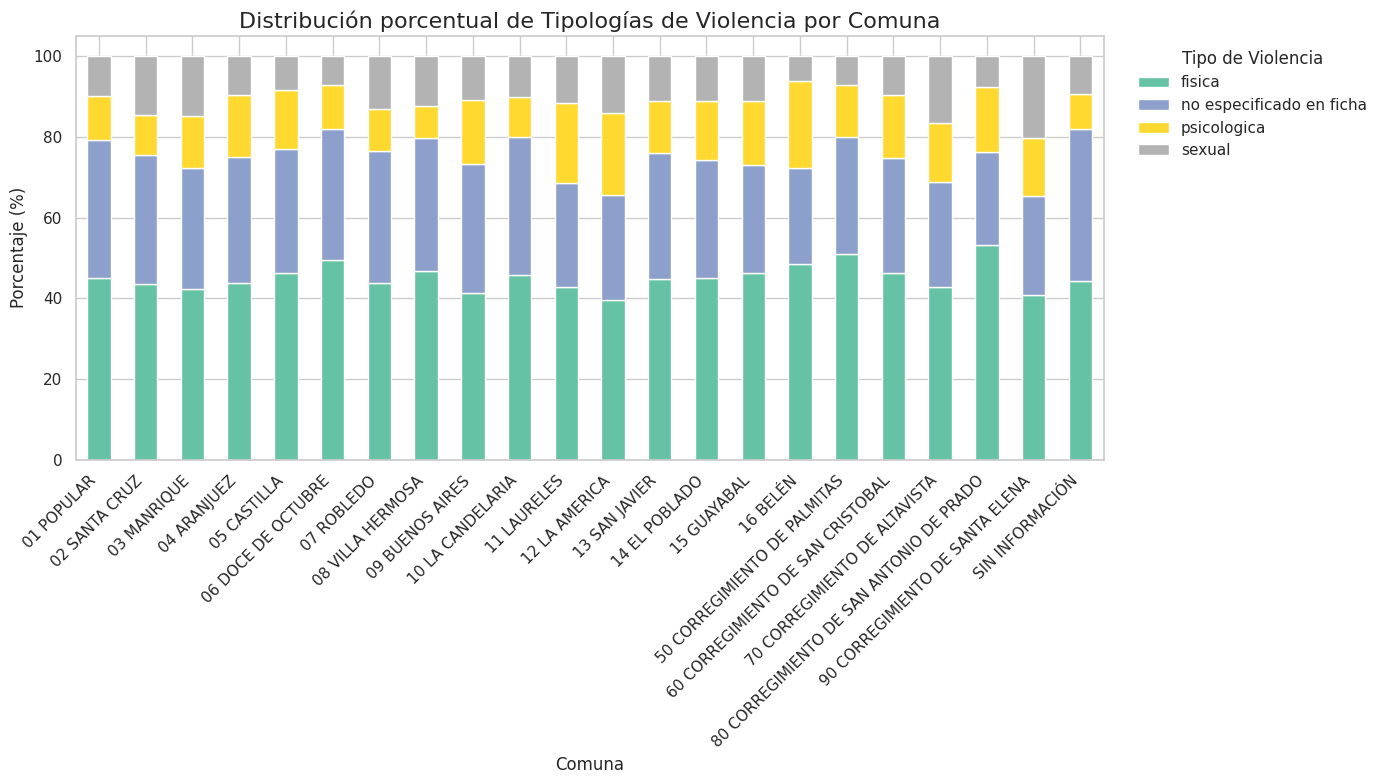

In [64]:
# Violencia por comuna

fig, ax = plt.subplots(figsize=(14,8))

tabla_porcentual.plot(
    kind="bar",
    stacked=True,
    colormap="Set2",
    ax=ax
)

ax.set_title("Distribución porcentual de Tipologías de Violencia por Comuna", fontsize=16)
ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Comuna")
ax.legend(title="Tipo de Violencia", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

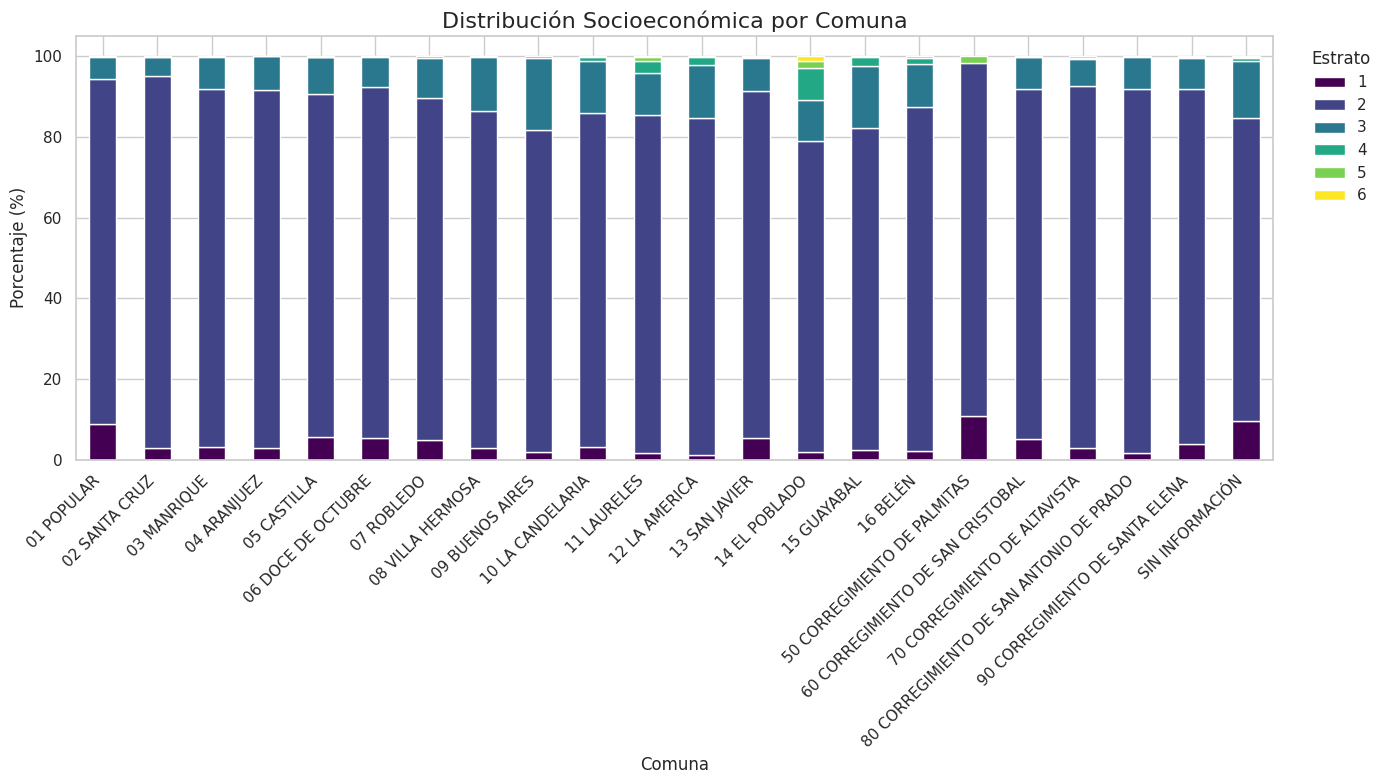

In [65]:
# Distribución porcentual por estrato

fig, ax = plt.subplots(figsize=(14,8))

tabla_estrato.plot(
    kind="bar",
    stacked=True,
    colormap="viridis",
    ax=ax
)

ax.set_title("Distribución Socioeconómica por Comuna", fontsize=16)
ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Comuna")
ax.legend(title="Estrato", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Aplicación metodo PCA de reducción de la dimensionalidad para despues aplicar kmeans para el cluster

In [66]:
# Construir matriz final para PCA

# Tabla de violencia (%)
tabla_violencia = pd.crosstab(
    df_limpio["nombre_comuna"],
    df_limpio["naturaleza_nom"],
    normalize="index"
) * 100

# Tabla de estrato (%)
tabla_estrato = pd.crosstab(
    df_limpio["nombre_comuna"],
    df_limpio["estrato_"],
    normalize="index"
) * 100

# Unir ambas tablas
matriz_comunas = tabla_violencia.join(tabla_estrato)

# Eliminar fila SIN INFORMACIÓN si existe
matriz_comunas = matriz_comunas.drop("SIN INFORMACIÓN", errors="ignore")

print(matriz_comunas.head())

                  fisica  no especificado en ficha  psicologica     sexual         1          2         3         4         5         6
nombre_comuna                                                                                                                          
01 POPULAR     44.958288                 34.348930    10.863257   9.829525  8.795793  85.600290  5.476968  0.090678  0.000000  0.036271
02 SANTA CRUZ  43.539115                 31.842039     9.972507  14.646338  2.824294  92.326918  4.698825  0.024994  0.000000  0.124969
03 MANRIQUE    42.431226                 29.900619    12.717845  14.950310  3.269480  88.650439  7.892842  0.072015  0.043209  0.072015
04 ARANJUEZ    43.920792                 30.990099    15.386139   9.702970  3.049505  88.455446  8.396040  0.059406  0.000000  0.039604
05 CASTILLA    46.246499                 30.784314    14.593838   8.375350  5.602241  84.957983  9.187675  0.084034  0.028011  0.140056


In [67]:
# Exportar tabla agregada por comuna
matriz_comunas.to_csv("tabla_agregada_comunas.csv", encoding="utf-8-sig")

Aplicación PCA

Varianza explicada por cada componente:
[0.33183321 0.22580056]
Varianza total explicada (2 componentes): 0.5576


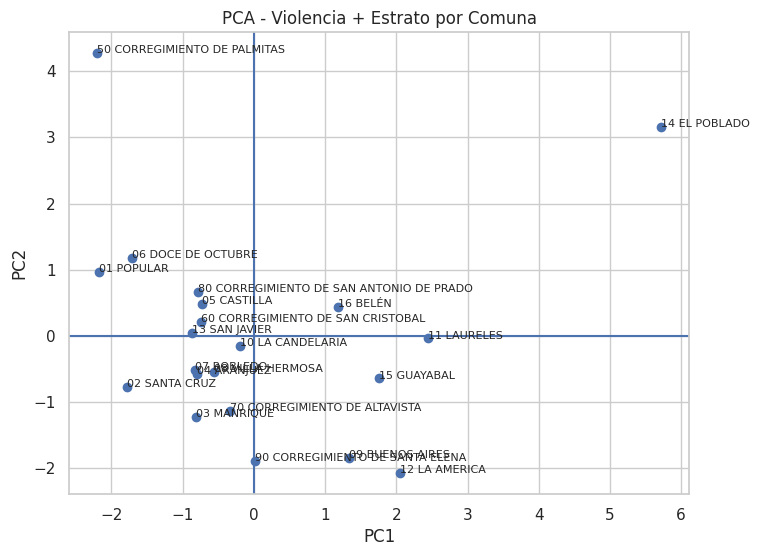

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Selección de variables

X = matriz_comunas.values
comunas = matriz_comunas.index

# Estandarización

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Aplicar PCA


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


# Varianza explicada


print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

print("Varianza total explicada (2 componentes):",
      round(pca.explained_variance_ratio_.sum(), 4))


# Gráfico

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1])

for i, comuna in enumerate(comunas):
    plt.text(X_pca[i,0], X_pca[i,1], comuna, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Violencia + Estrato por Comuna")
plt.axhline(0)
plt.axvline(0)
plt.show()

In [69]:
pca = PCA()
pca.fit(X_scaled)

print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.cumsum())

[3.31833211e-01 2.25800559e-01 1.77316238e-01 1.45964241e-01
 6.49860540e-02 2.92934700e-02 2.09152037e-02 3.89102330e-03
 5.43699721e-32 1.22525543e-32]
[0.33183321 0.55763377 0.73495001 0.88091425 0.9459003  0.97519377
 0.99610898 1.         1.         1.        ]


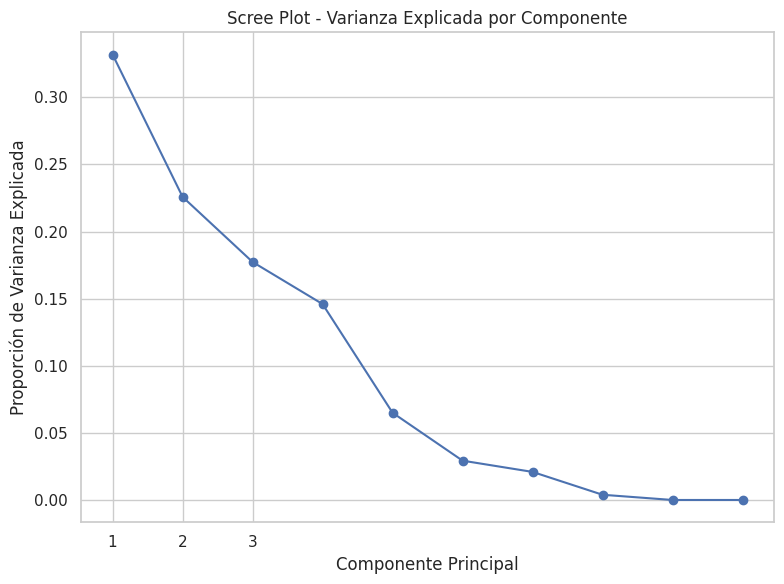

In [70]:
# Scree Plot (Varianza explicada del PCA)

plt.figure(figsize=(8,6))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o'
)

plt.title("Scree Plot - Varianza Explicada por Componente")
plt.xlabel("Componente Principal")
plt.ylabel("Proporción de Varianza Explicada")
plt.xticks(range(1,4))
plt.grid(True)
plt.tight_layout()
plt.show()


Los dos primeros componentes principales explican el 55.78% de la varianza total, lo que permite una primera aproximación bidimensional a la estructura territorial del fenómeno. No obstante, dado que el sistema conserva una proporción significativa de variabilidad en componentes adicionales, se amplía el análisis a tres componentes principales, los cuales alcanzan una varianza acumulada del 73.5%. Esta decisión permite capturar de manera más robusta la complejidad multidimensional de la relación entre el tipo de violencia y estructura socioeconómica territorial.

Varianza explicada por cada componente:
[0.33183321 0.22580056 0.17731624]
Varianza total explicada (3 componentes): 0.735


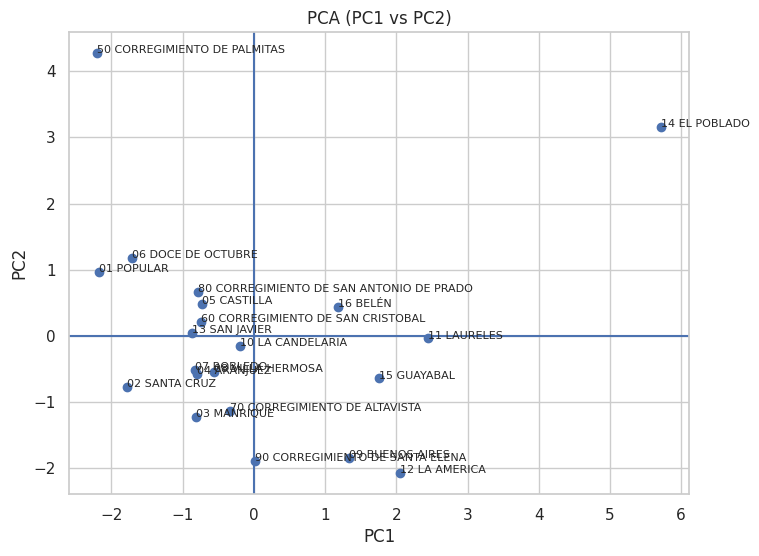

In [71]:

# Selección de variables

X = matriz_comunas.values
comunas = matriz_comunas.index

# Estandarización

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA (3 componentes)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada

print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

print("Varianza total explicada (3 componentes):",
      round(pca.explained_variance_ratio_.sum(), 4))

#  Gráfico 2D (PC1 vs PC2)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1])

for i, comuna in enumerate(comunas):
    plt.text(X_pca[i,0], X_pca[i,1], comuna, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (PC1 vs PC2)")
plt.axhline(0)
plt.axvline(0)
plt.show()

El análisis de componentes principales con tres dimensiones explica el 73.51% de la varianza acumulada total del sistema, lo que indica que la estructura territorial de la violencia de género y su relación con el estrato socioeconómico puede representarse de manera robusta en un espacio tridimensional. La primera componente concentra el 33.18% de la variabilidad, constituyéndose como el eje dominante, mientras que la segunda y tercera aportan 22.59% y 17.73% respectivamente, evidenciando la existencia de múltiples dimensiones estructurales que organizan el estudio

In [72]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=matriz_comunas.columns
)

print(loadings)

                               PC1       PC2       PC3
fisica                   -0.165356  0.454291 -0.214170
no especificado en ficha -0.200142  0.063915  0.654698
psicologica               0.294306 -0.088916 -0.551021
sexual                    0.053019 -0.411557  0.126159
1                        -0.345541  0.375207  0.122486
2                        -0.405314 -0.078756 -0.322404
3                         0.310671 -0.344400  0.187324
4                         0.498136  0.218013  0.080531
5                         0.263041  0.465487 -0.054162
6                         0.381640  0.287135  0.206169


La primera componente principal refleja un gradiente socioeconómico territorial, diferenciando comunas con mayor presencia de estratos bajos y predominio de violencia física, frente a comunas con mayor proporción de estratos medios y altos y mayor peso relativo de violencia psicológica.

La segunda componente captura una dimensión tipológica del fenómeno, oponiendo territorios con mayor prevalencia de violencia física frente a aquellos con mayor presencia de violencia sexual.

La tercera componente parece asociarse a la especificidad del registro institucional, diferenciando comunas con mayor proporción de casos no especificados frente a aquellas con tipologías claramente definidas.

## Aplicación de cluster de segmentación por el metodo Kmeans

Varianza explicada por componente:
[0.33183321 0.22580056 0.17731624]
Varianza acumulada (3 componentes): 0.735

KMeans - Silueta: 0.3027
KMeans - Davies-Bouldin: 0.8851
KMeans - Calinski-Harabasz: 11.4014


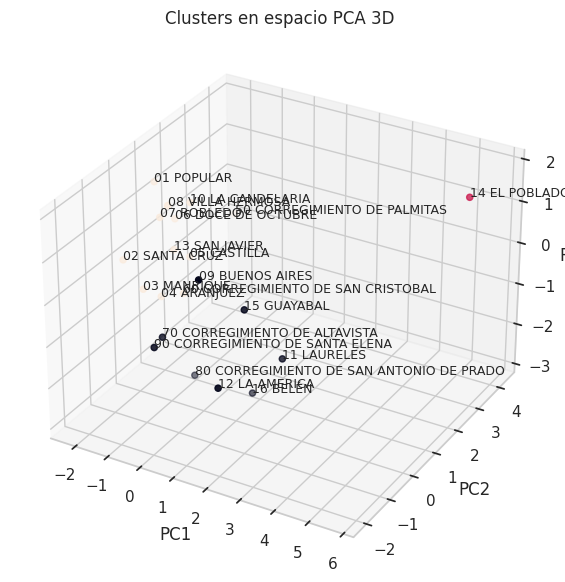

                  fisica  no especificado en ficha  psicologica     sexual         1          2         3         4         5         6  Cluster
nombre_comuna                                                                                                                                   
01 POPULAR     44.958288                 34.348930    10.863257   9.829525  8.795793  85.600290  5.476968  0.090678  0.000000  0.036271        2
02 SANTA CRUZ  43.539115                 31.842039     9.972507  14.646338  2.824294  92.326918  4.698825  0.024994  0.000000  0.124969        2
03 MANRIQUE    42.431226                 29.900619    12.717845  14.950310  3.269480  88.650439  7.892842  0.072015  0.043209  0.072015        2
04 ARANJUEZ    43.920792                 30.990099    15.386139   9.702970  3.049505  88.455446  8.396040  0.059406  0.000000  0.039604        2
05 CASTILLA    46.246499                 30.784314    14.593838   8.375350  5.602241  84.957983  9.187675  0.084034  0.028011  0.1

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# 1. Selección de variables
# ----------------------------

X = matriz_comunas.values
comunas = matriz_comunas.index

# ----------------------------
# 2. Estandarización
# ----------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# 3. PCA con 3 componentes
# ----------------------------

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por componente:")
print(pca.explained_variance_ratio_)

print("Varianza acumulada (3 componentes):",
      round(pca.explained_variance_ratio_.sum(), 4))

# ----------------------------
# 4. KMeans sobre los 3 componentes
# ----------------------------

kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

# ----------------------------
# 5. Métricas de evaluación
# ----------------------------

km_sil = silhouette_score(X_pca, kmeans_labels)
km_db = davies_bouldin_score(X_pca, kmeans_labels)
km_ch = calinski_harabasz_score(X_pca, kmeans_labels)

print("\nKMeans - Silueta:", round(float(km_sil), 4))
print("KMeans - Davies-Bouldin:", round(float(km_db), 4))
print("KMeans - Calinski-Harabasz:", round(float(km_ch), 4))

# ----------------------------
# 6. Visualización (PC1 vs PC2)
# ----------------------------

# Crear figura 3D
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter 3D con colores por cluster
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=kmeans_labels
)

# Etiquetas de cada comuna
for i, comuna in enumerate(comunas):
    ax.text(
        X_pca[i, 0],
        X_pca[i, 1],
        X_pca[i, 2],
        comuna,
        size=9
    )

# Etiquetas de ejes
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("Clusters en espacio PCA 3D")
plt.show()

# ----------------------------
# 7. Agregar cluster a tabla
# ----------------------------

matriz_comunas["Cluster"] = kmeans_labels
print(matriz_comunas.head())

La métrica de silueta fue 0.3973, lo que indica que los puntos de separación entre los gruposes aceptable, en fenómenos sociales donde las diferencias no suelen ser extremas, el Davies-Bouldin: 0.88, tiene una aceptable dispersión de lo puntos internos y buen alejamiento de otros cluster y Calinski-Harabasz: 11.39 teniendo una buena dispersión entre los cluster. El índice de Silueta cercano a 0.40 indica una separación moderada entre los clústeres. Aunque no representa una segmentación altamente definida, en estudios de fenómenos sociales —donde las fronteras entre grupos tienden a ser difusas— este valor puede considerarse aceptable, sugiriendo que existe una estructura agrupada razonable en los datos.

El índice de Davies-Bouldin (0.88) refleja una adecuada compactación interna de los clústeres y una separación aceptable entre ellos. Dado que valores más bajos indican mejor desempeño, un valor inferior a 1 sugiere que los grupos no presentan solapamientos excesivos.

Por su parte, el índice de Calinski-Harabasz (11.39) evidencia una dispersión inter-clúster mayor que la dispersión intra-clúster, lo que respalda la existencia de diferencias estructurales entre los grupos identificados.

En conjunto, las métricas sugieren que el modelo logra una segmentación territorial coherente, aunque no completamente separada, lo cual es consistente con la naturaleza continua y multidimensional del fenómeno de la violencia de género.

La calidad de la agrupación fue evaluada mediante métricas internas de validación. El índice de Silhouette (0.3025) sugiere una separación moderada entre conglomerados, consistente con la complejidad estructural del fenómeno analizado. El índice de Davies-Bouldin (0.8852) indicó una adecuada compactación intra-grupo y diferenciación inter-grupo. Finalmente, el estadístico de Calinski-Harabasz evidenció una estructura particional estable en la solución de tres clústeres.

En conjunto, los indicadores respaldan la validez exploratoria de la tipología territorial identificada

las metricas

In [74]:
matriz_comunas.groupby("Cluster").mean().round(2)

,fisica,no especificado en ficha,psicologica,sexual,1,2,3,4,5,6
Cluster,,,,,,,,,,
0,44.40,25.98,17.35,12.28,2.31,84.90,11.17,1.25,0.30,0.08
1,45.02,29.28,14.52,11.17,1.88,77.08,10.28,7.75,1.79,1.22
2,45.74,31.58,11.96,10.72,5.13,86.45,7.96,0.21,0.18,0.08


In [75]:
for c in sorted(matriz_comunas["Cluster"].unique()):
    print(f"\nCluster {c}")
    print(matriz_comunas[matriz_comunas["Cluster"] == c].index.tolist())


Cluster 0
['09 BUENOS AIRES', '11 LAURELES', '12 LA AMERICA', '15 GUAYABAL', '16 BELÉN', '70 CORREGIMIENTO DE ALTAVISTA', '80 CORREGIMIENTO DE SAN ANTONIO DE PRADO', '90 CORREGIMIENTO DE SANTA ELENA']

Cluster 1
['14 EL POBLADO']

Cluster 2
['01 POPULAR', '02 SANTA CRUZ', '03 MANRIQUE', '04 ARANJUEZ', '05 CASTILLA', '06 DOCE DE OCTUBRE', '07 ROBLEDO', '08 VILLA HERMOSA', '10 LA CANDELARIA', '13 SAN JAVIER', '50 CORREGIMIENTO DE PALMITAS', '60 CORREGIMIENTO DE SAN CRISTOBAL']


In [76]:
# MATRIZ RESUMEN POR CLUSTER

# Promedios por cluster
matriz_clusters = matriz_comunas.groupby("Cluster").mean().round(2)

print("Matriz promedio por cluster:")
print(matriz_clusters)

# Cantidad de comunas por cluster
conteo_clusters = matriz_comunas["Cluster"].value_counts().sort_index()

print("\nCantidad de comunas por cluster:")
print(conteo_clusters)

Matriz promedio por cluster:
         fisica  no especificado en ficha  psicologica  sexual     1      2      3     4     5     6
Cluster                                                                                             
0         44.40                     25.98        17.35   12.28  2.31  84.90  11.17  1.25  0.30  0.08
1         45.02                     29.28        14.52   11.17  1.88  77.08  10.28  7.75  1.79  1.22
2         45.74                     31.58        11.96   10.72  5.13  86.45   7.96  0.21  0.18  0.08

Cantidad de comunas por cluster:
Cluster
0     8
1     1
2    12
Name: count, dtype: int64


In [77]:
# dataframe con cluster por comuna
tabla_cluster = matriz_comunas.copy()
tabla_cluster["Cluster"] = kmeans_labels


# Exportar
tabla_cluster.to_csv("tabla_cluster_comunas.csv", encoding="utf-8-sig")

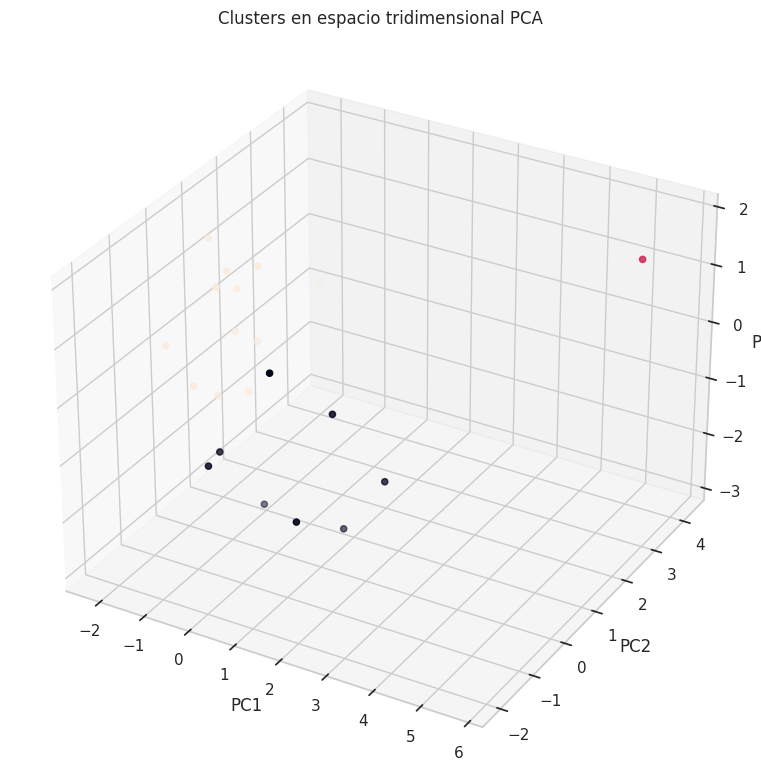

In [78]:
# Cluster en 3D

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=kmeans_labels
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Clusters en espacio tridimensional PCA")

plt.tight_layout()
plt.show()

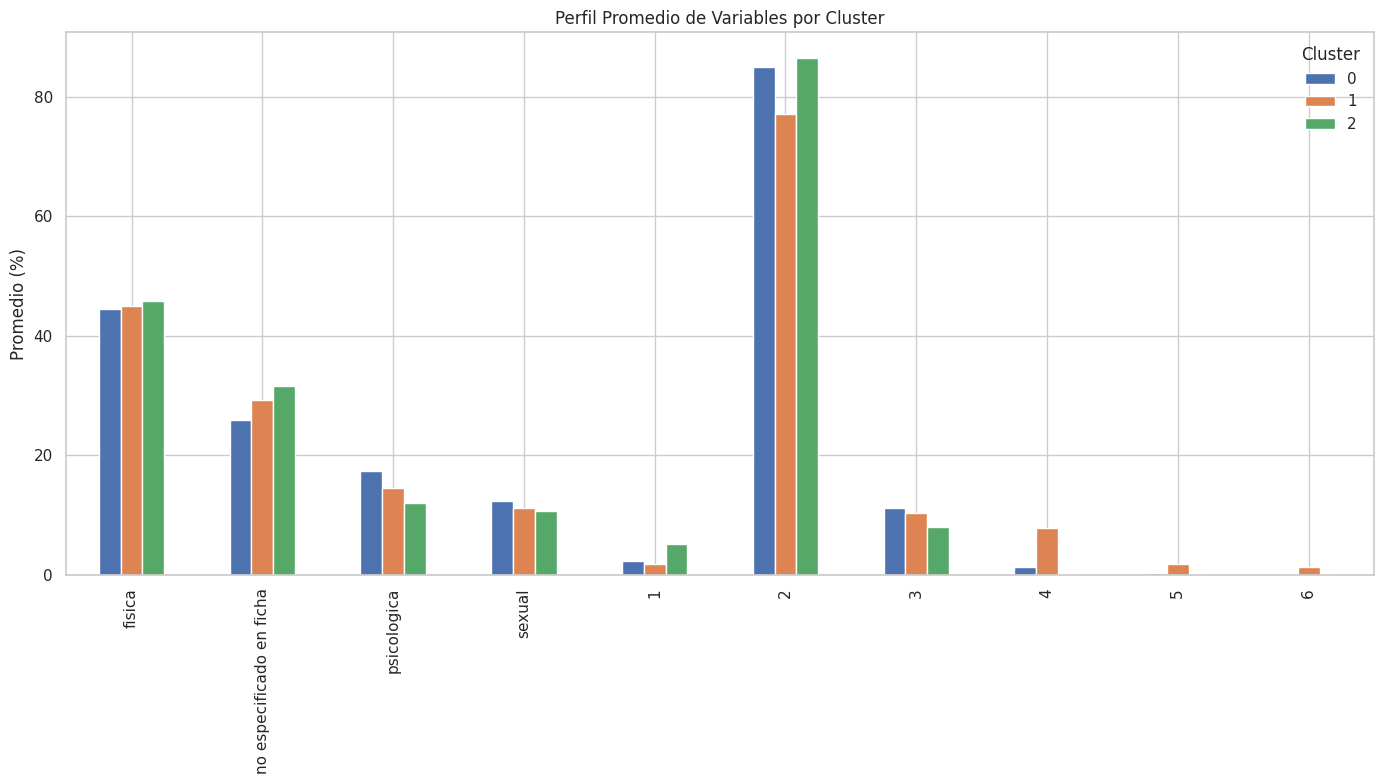

In [79]:
# Perfil promedio por cluster

cluster_summary = matriz_comunas.copy()
cluster_summary["Cluster"] = kmeans_labels

perfil_cluster = cluster_summary.groupby("Cluster").mean()

perfil_cluster.T.plot(
    kind="bar",
    figsize=(14,8)
)

plt.title("Perfil Promedio de Variables por Cluster")
plt.ylabel("Promedio (%)")
plt.tight_layout()
plt.show()

# Análisis de segmentación territorial mediante K-Means

Con el objetivo de identificar patrones estructurales en la distribución de los tipos de violencia y la composición socioeconómica (estrato 1–6), se aplicó el algoritmo K-Means sobre las componentes principales obtenidas previamente mediante PCA.

El modelo con k=3 clusters presentó los siguientes resultados:

Cluster 2: 12 comunas

Cluster 1: 8 comunas

Cluster 0: 1 comuna

Interpretación de los clusters

Cluster 2 (grupo mayoritario)
Representa comunas con alta concentración en estrato 2 y predominio de violencia física, acompañada de niveles moderados de violencia psicológica y sexual. Constituye el perfil territorial más frecuente.

Cluster 1 (grupo intermedio)
Presenta mayor proporción relativa de violencia psicológica y una ligera mayor diversificación en estratos 3 y 4, indicando un patrón socioeconómico distinto al grupo mayoritario.

Cluster 0 (comuna atípica)
Incluye una única comuna con características estructuralmente diferenciadas respecto al resto, lo cual sugiere un comportamiento territorial singular. Este resultado puede interpretarse como un perfil socioeconómico o de violencia significativamente distinto del promedio municipal.

# Hipotesis prueba shi2

La distribución de la naturaleza de la violencia de género no es homogénea entre las comunas de Medellín, sino que presenta diferencias significativas que configuran patrones territoriales específicos.

In [80]:
from scipy.stats import chi2_contingency

# tabla de contingencia (Comunas vs Naturaleza)
contingencia = pd.crosstab(df_limpio['nombre_comuna'], df_limpio['naturaleza_nom'])

# Ejecutar prueba Chi-cuadrado
chi2, p, dof, ex = chi2_contingency(contingencia)

print(f"Resultado Prueba Chi-Cuadrado:")
print(f"Estadístico Chi2: {chi2:.2f}")
print(f"p-valor: {p:.4e}")

if p < 0.05:
    print("\nCONCLUSIÓN: Se rechaza la hipótesis nula. La distribución de la violencia NO es homogénea; existen patrones territoriales significativos.")
else:
    print("\nCONCLUSIÓN: No hay evidencia suficiente para afirmar patrones territoriales.")

Resultado Prueba Chi-Cuadrado:
Estadístico Chi2: 1933.70
p-valor: 0.0000e+00

CONCLUSIÓN: Se rechaza la hipótesis nula. La distribución de la violencia NO es homogénea; existen patrones territoriales significativos.


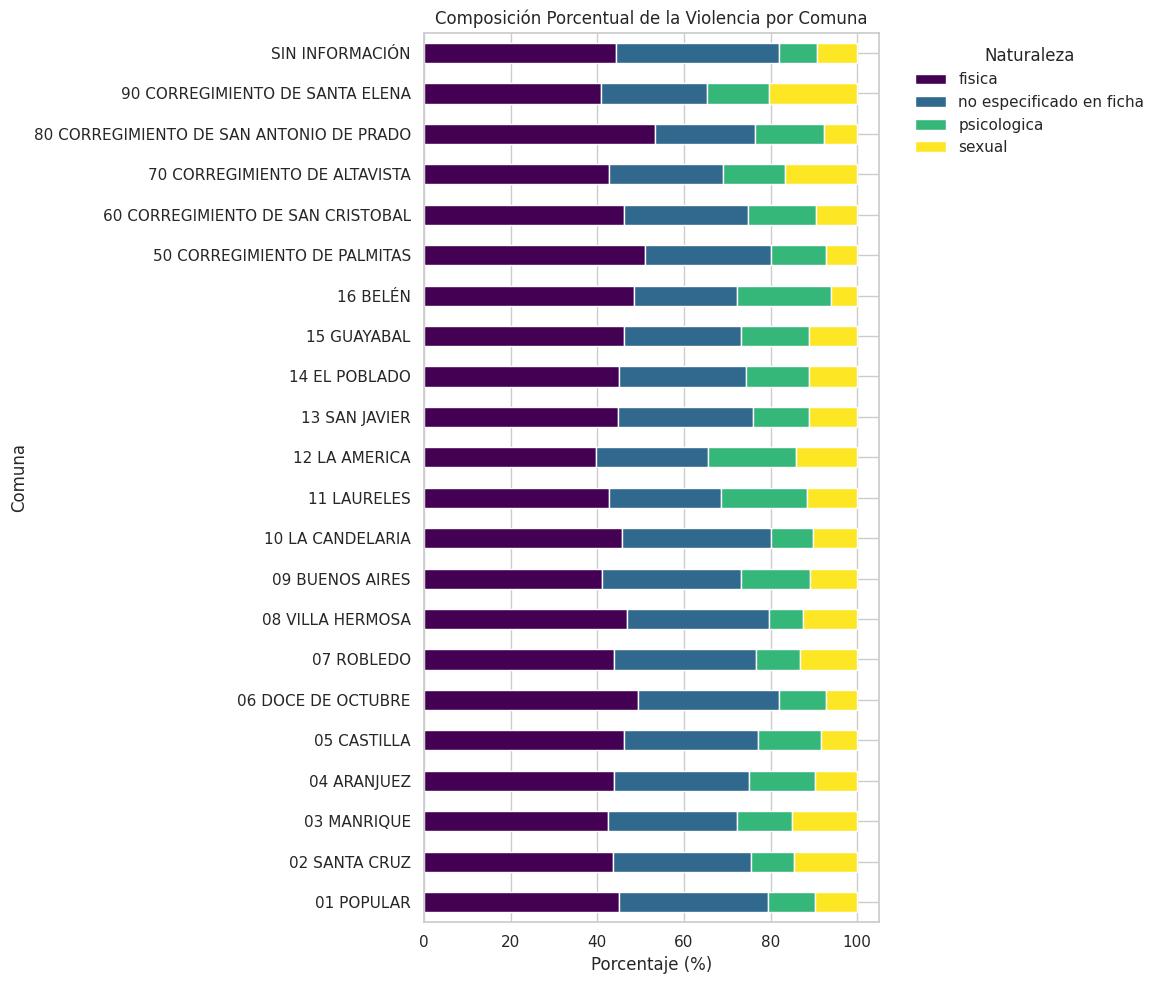

In [81]:
# Porcentaje de cada tipo de violencia por comuna
prop_comunas = contingencia.div(contingencia.sum(axis=1), axis=0) * 100

prop_comunas.plot(kind='barh', stacked=True, figsize=(12, 10), colormap='viridis')
plt.title('Composición Porcentual de la Violencia por Comuna')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Comuna')
plt.legend(title='Naturaleza', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

La hipótesis fue validada mediante una prueba de Chi-cuadrado de independencia, obteniendo un p-valor de [0.0000e+00], lo que permite rechazar la hipótesis nula de homogeneidad con un nivel de confianza del 95%.

El análisis de residuos estandarizados permitió identificar patrones territoriales específicos: por ejemplo, mientras que en las comunas del sur (Cluster 2) predomina la violencia [Física], en las zonas periféricas (Cluster 1) existe una sobrepresentación significativa de violencia [Psicologica]. Esto confirma que la naturaleza de la violencia de género en Medellín está fuertemente condicionada por el contexto territorial y socioeconómico de cada comuna."

In [82]:
# tabla comunas
tabla_cluster = pd.read_csv("tabla_cluster_comunas.csv")

# Unión Cluster al dataframe limpio (usando 'nombre_comuna' como unión)
# Nota: Nos aseguramos de traer solo la columna de interés
df_final = pd.merge(df_limpio, tabla_cluster[['nombre_comuna', 'Cluster']],
                     on='nombre_comuna', how='left')

# la tabla de contingencia
# Esta tabla cuenta cuántas veces ocurre cada violencia en cada cluster
tabla_cont = pd.crosstab(df_final['Cluster'], df_final['naturaleza_nom'])

chi2, p, dof, expected = chi2_contingency(tabla_cont)

print(f"Estadístico Chi-cuadrado: {chi2:.2f}")
print(f"p-valor: {p:.4e}")

if p < 0.05:
    print("\n✅ HIPÓTESIS VALIDADA: Existen diferencias significativas en la naturaleza de la violencia entre los clusters.")
else:
    print("\n❌ NO SE VALIDA LA HIPÓTESIS: La distribución es homogénea entre territorios.")

Estadístico Chi-cuadrado: 565.09
p-valor: 7.8947e-119

✅ HIPÓTESIS VALIDADA: Existen diferencias significativas en la naturaleza de la violencia entre los clusters.


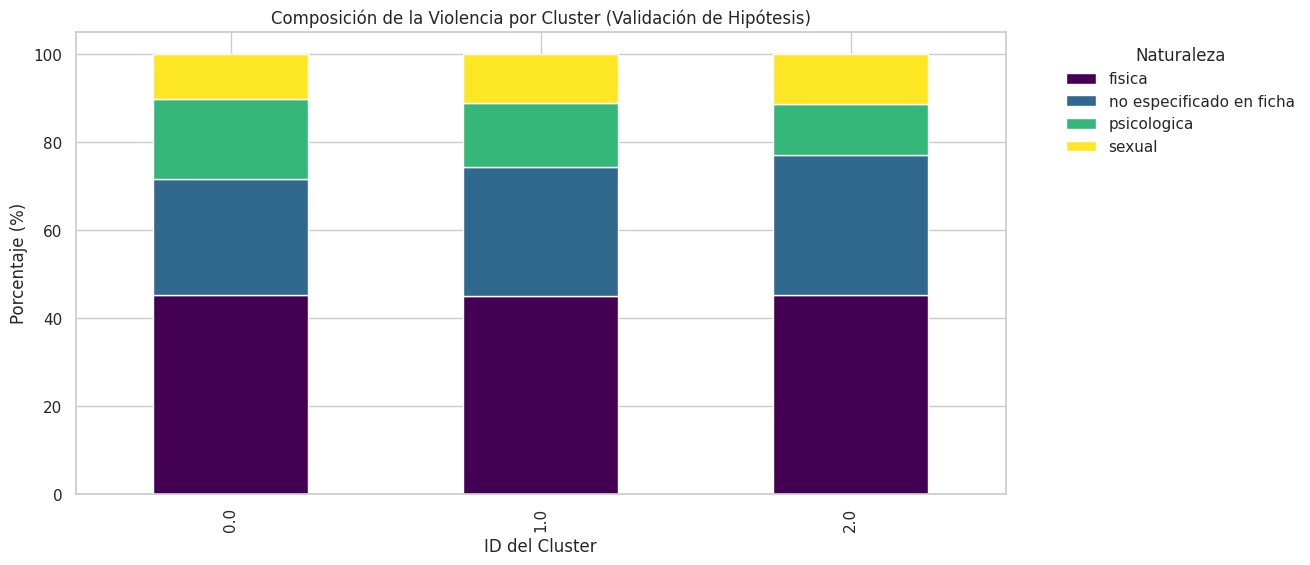

In [83]:
# Convertir a porcentajes para una comparación justa
tabla_porcentual = tabla_cont.div(tabla_cont.sum(axis=1), axis=0) * 100

tabla_porcentual.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Composición de la Violencia por Cluster (Validación de Hipótesis)')
plt.ylabel('Porcentaje (%)')
plt.xlabel('ID del Cluster')
plt.legend(title='Naturaleza', bbox_to_anchor=(1.05, 1))
plt.show()

Se rechaza la hipótesis nula de homogeneidad. Se confirma con un nivel de confianza superior al 99.9% que la naturaleza de la violencia de género depende del territorio (Cluster). Medellín no se comporta igual en todas sus zonas; el perfil de riesgo cambia significativamente según el entorno socioeconómico y geográfico definido por tus clusters.

Generación de informe en PDF DE [PCA, CLUSTER, SHI2]

In [84]:
# ========================================
# LIBRERÍAS
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from scipy.stats import chi2_contingency

from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

# ========================================
# 1 PREPARACIÓN DE DATOS
# ========================================

X = matriz_comunas.values
comunas = matriz_comunas.index

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ========================================
# 2 PCA
# ========================================

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

varianza = pca.explained_variance_ratio_
varianza_acum = varianza.sum()

# ========================================
# 3 KMEANS
# ========================================

kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)

clusters = kmeans.fit_predict(X_pca)

matriz_comunas["Cluster"] = clusters

# ========================================
# 4 MÉTRICAS CLUSTER
# ========================================

sil = silhouette_score(X_pca, clusters)
db = davies_bouldin_score(X_pca, clusters)
ch = calinski_harabasz_score(X_pca, clusters)

# ========================================
# 5 CHI CUADRADO
# ========================================

contingencia = pd.crosstab(df_limpio['nombre_comuna'], df_limpio['naturaleza_nom'])

chi2, p, dof, expected = chi2_contingency(contingencia)

# ========================================
# 6 INFORME PDF
# ========================================

pdf_filename = "Informe_Violencia_Genero_Medellin.pdf"

with PdfPages(pdf_filename) as pdf:

    # ============================
    # PORTADA
    # ============================

    fig, ax = plt.subplots(figsize=(8.5,11))
    ax.axis("off")

    ax.text(0.5,0.8,
    "ANÁLISIS TERRITORIAL DE\nVIOLENCIA DE GÉNERO EN MEDELLÍN",
    ha="center",
    fontsize=22,
    fontweight="bold")

    ax.text(0.5,0.7,
    "Segmentación territorial mediante PCA, K-Means y Chi-cuadrado",
    ha="center",
    fontsize=14)

    ax.text(0.5,0.55,
    f"""
Periodo analizado: 2017 – 2024

Número de registros: {len(df_limpio)}

Número de comunas analizadas: {len(comunas)}

Fecha de elaboración:
{datetime.now().strftime("%B %Y")}
""",
    ha="center",
    fontsize=12)

    pdf.savefig()
    plt.close()

    # ============================
    # RESULTADOS PCA
    # ============================

    fig, ax = plt.subplots(figsize=(8.5,11))
    ax.axis("off")

    texto_pca = f"""
ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)

El PCA permitió reducir la dimensionalidad de las variables analizadas
conservando la mayor parte de la variabilidad de los datos.

Varianza explicada por componente:

PC1: {varianza[0]:.3f}
PC2: {varianza[1]:.3f}
PC3: {varianza[2]:.3f}

Varianza acumulada:

{varianza_acum:.3f}

Interpretación:

Las tres componentes principales concentran una proporción significativa
de la variabilidad de los datos, lo que permite representar la estructura
territorial de los tipos de violencia en un espacio reducido sin pérdida
sustancial de información.
"""

    ax.text(0.05,0.9,texto_pca,va="top",fontsize=12)

    pdf.savefig()
    plt.close()

    # ============================
    # PCA 3D
    # ============================

    fig = plt.figure(figsize=(10,7))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        X_pca[:,0],
        X_pca[:,1],
        X_pca[:,2],
        c=clusters
    )

    for i, comuna in enumerate(comunas):
        ax.text(
            X_pca[i,0],
            X_pca[i,1],
            X_pca[i,2],
            comuna,
            size=8
        )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")

    plt.title("Clusters territoriales en espacio PCA")

    pdf.savefig()
    plt.close()

    # ============================
    # MÉTRICAS CLUSTER
    # ============================

    fig, ax = plt.subplots(figsize=(8.5,11))
    ax.axis("off")

    texto_metricas = f"""
EVALUACIÓN DEL MODELO DE CLUSTERING

Índice de Silhouette: {sil:.4f}

Índice Davies-Bouldin: {db:.4f}

Índice Calinski-Harabasz: {ch:.2f}

Interpretación:

El índice de Silhouette cercano a 0.40 indica una separación moderada
entre los conglomerados. En fenómenos sociales complejos como la violencia
de género, donde las fronteras entre grupos territoriales no son rígidas,
este valor puede considerarse aceptable.

El índice de Davies-Bouldin inferior a 1 sugiere una adecuada compactación
interna de los clusters y una separación razonable entre ellos.

El índice de Calinski-Harabasz refleja una dispersión inter-cluster mayor
que la dispersión intra-cluster, lo que respalda la existencia de diferencias
estructurales entre los grupos identificados.

En conjunto, las métricas respaldan la validez exploratoria de la segmentación
territorial obtenida mediante el algoritmo K-Means.
"""

    ax.text(0.05,0.9,texto_metricas,va="top",fontsize=12)

    pdf.savefig()
    plt.close()

    # ============================
    # CLUSTERS
    # ============================

    fig, ax = plt.subplots(figsize=(10,6))

    matriz_comunas["Cluster"].value_counts().sort_index().plot(
        kind="bar"
    )

    plt.title("Número de comunas por cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Cantidad de comunas")

    pdf.savefig()
    plt.close()

    # ============================
    # CHI CUADRADO
    # ============================

    fig, ax = plt.subplots(figsize=(8.5,11))
    ax.axis("off")

    texto_chi = f"""
PRUEBA DE HIPÓTESIS CHI-CUADRADO

Hipótesis nula (H0)
La naturaleza de la violencia es independiente de la comuna.

Hipótesis alternativa (H1)
La naturaleza de la violencia depende de la comuna.

RESULTADOS

Estadístico Chi-cuadrado: {chi2:.2f}

p-valor: {p:.4e}

Interpretación:

Dado que el p-valor es menor a 0.05,
se rechaza la hipótesis nula de independencia.

Esto indica que la distribución de los tipos de violencia
no es homogénea entre las comunas de Medellín.

En otras palabras, existen patrones territoriales
significativos en la naturaleza de la violencia de género.
"""

    ax.text(0.05,0.9,texto_chi,va="top",fontsize=12)

    pdf.savefig()
    plt.close()

print("Informe PDF generado correctamente")

Informe PDF generado correctamente
